<h1 align="center">AI Tools &amp; Techniques For Cybersecurity</h1>
<h2 align="center">Jupyter Notebook Code and Dataset Analysis</h2>

<br>

<div align="center">
  <p><strong>Student Name:</strong> Jay Tan Chee Leong &nbsp; | &nbsp; <strong>Student Number:</strong> S10270577</p>
  <p><strong>Student Name:</strong> Joel Tan &nbsp; | &nbsp; <strong>Student Number:</strong> S10267388</p>
  <p><strong>Student Name:</strong> Ng QianZheng Darrius &nbsp; | &nbsp; <strong>Student Number:</strong> S10267368</p>
</div>

# 1. Business Understanding

Business Understanding consists of defining the problem, context and objectives before working with the data. It explains the goal and the purpose of the data analysis process.

## 1.1. Problem Background

Internet of Things (IoT) devices are increasingly being utilised in everyday items and environments such as smartwatches, homes, enterprises and networks. These devices continuously generate large volumes of netowrk traffic and often operate with limited built-in security. Many modern network security solutions are incapable of detecting IoT devices making them vulnerable to cyber threats due to weak authentication, poor encryption, and difficulty in patching and updating firmware. As a result, IoT devices are exposed to a large attack surface where they are frequently a target to malicious activities and cyberattacks, highlighting the importance of analysing network traffic associated to IoT devices to better understand the indicators of IoT attacks at the network level.

## 1.2. Problem Statement

**Problem Statement:**

With the rise of IoT devices, it has led to complex and diverse network traffic patterns, making it difficult to effectively detect and categorise cyberattacks. IoT devices are exposed to various cyberattacks which exhibit differnt traffic behaviours, complicating the identification of any malicious activitiy. While security platforms such as Security Information and Event Management (SIEM) systems exist to monitor and analyse network activity, they often rely on predefined rules and signatures which may not effectively capture the differnt indicators and patterns with the rise of IoT attacks. To address this problem, this dataset analysis is conducted to examine IoT traffic data and to better understand how benign and malicious traffic differ across multiple attack categories. It allows us to utilise AI to accurately make data-driven detections, predictions and visualisations for IoT attacks.

**How Might We Statement:**

How might we leverage IoT network traffic data from the TabularIoTAttack-2024 dataset to accurately distinguish between benign traffic and multiple IoT-specific cyberattack categories in a data-driven manner?

## 1.3. Analysis Objective

The objective of the analysis is to examine the structure, characteristics and network traffic indicators during a IoT-specific cyberattack. Through analysis, the aim is to identify relevant features, headers, attack distributions within the dataset. The outcome of the analysis is to create a well structured and clean dataset that is suitable for all stages of the data science lifecycle including business understanding, data mining, data cleaning, data exploration, feature engineering, predictive modelling and data visualisation.

## 1.4. Dataset Overview

The **CIC-BCCC-NRC TabularIoTAttack-2024** dataset is a comprehensive publicly available IoT network traffic dataset created by the Canadian Institute for Cybersecurity (CIC), the Behavioural Centric Cybersecurity Centre (BCCC), and the National Research Council (NRC) of Canada. This dataset supports reseasrch in IoT cybersecurity and intrision detection. The dataset features efforts to create a reliable source for training and testing AI-powered IoT cyberseucity models. The aim of the dataset is to address the modern challenges in detection and identification in IoT specific cyberattacks using data which reflects realistic IoT network behaviours.

Data was generated using real-world IoT devices and simulated attack scenarios which were conducted within controlled lab enviornments.

The dataset is provided as 12 CSV files, with each representing a specific IoT traffic category, including benign traffic and various IoT-specific cyberattacks. 

Dataset includes 12 attack categories:
- **Benign Traffic** - Normal IoT device communication
- **DoS Attacks** - DNS Flood, ICMP Flood, SYN Flood, UDP Flood
- **Reconnaissance Attacks** - Host Discovery, OS Scan, Ping Sweep, Port Scan, Vulnerability Scan
- **Brute Force Attacks** - Dictionary Brute Force
- **MITM Attacks** - ARP Spoofing

The dataset contains a total of **722,144 records** across **85 features**. Each record represents a bidirectional network flow with statistical features that describe packet behavior, timing patterns, and TCP characteristics. The structure and richness of the dataset make it suitable for understanding network-level indicators of IoT attacks prior to data cleaning, feature engineering, and predictive modelling.

**Source:** https://www.unb.ca/cic/datasets/tabular-iot-attack-2024.html

# 2. Data Mining

Data Mining allows the processing, validation and consolidation of raw data into a usable form for analysis. It locates, combines and loads various data from various sources while verifying its schema and structual consistency. The objective of this stage is to ensure that the dataset is complete, consistent, and ready the next stages of the data science lifecycle, such as dataset cleaning, exploration, modelling and visualisation.

## 2.1. Importing Libraries

Libraries are required for data ingestion, maniputation and file system operations throughout the notebook. They provide the functions required to load, inspect, model, predict, and visualise the data imported. 

Libraries imported consist of Pandas, NumPy, Matplotlib, Seaborn and Pathlib.

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from sklearn.preprocessing import RobustScaler


# Path helps us in the following ways:
# 1. Handle file paths
# 2. Make it easier to combine folders + filenames
from pathlib import Path

%matplotlib inline

print("Libraries successfully imported.")

Libraries successfully imported.


## 2.2. Locating CSV Files

The CIC-BCCC-NRC TabularIoTAttack-2024 comprises of 12 CSV files, each representing IoT attack categories. To ensure effective loading of the datasets and scalability, a relative directory path should be utilised to loacate all relevant datasets regardless of where the CSV files are saved on a user's system. Pathlib module is imported to facilitate this process. It enables the identifying of all CSV files within the defined directory, and allows us to access them without the need for hard-coded absolute paths.

The following steps are done to locate all relevant CSV files to the dataset, and display the number of files found within the defined directory where the files are saved.

In [161]:
# Pathlib module is imported and utilised in the following code
# from pathlib import Path

# Defines the relative path to the dataset directory where 'Datasets' is the directory which contains all releavnt CSV files
# Path() function creates a relative path ensuring that the code works on different operating systems.
dataset_directory = Path("Datasets")

# Retrives the CSV files within the "Datasets" directory
# sorted() ensures that files are processed in a consistent and efficient order
# .glob("*.csv") searches the directory for all files with the extension of .csv, which is common to all the dataset files for our chosen dataset
csv_files = sorted(dataset_directory.glob("*.csv"))

# Display number of files discovered
print(f"Number of CSV files found: {len(csv_files)}")
print(f"\nFiles Identified:")
print("-----------------")

for index, file in enumerate(csv_files, start=1):
    
    print(f"{index}. {file.name}")


Number of CSV files found: 12

Files Identified:
-----------------
1. Benign Traffic.csv
2. Dictionary Brute Force.csv
3. DoS DNS Flood.csv
4. DoS ICMP Flood.csv
5. DoS SYN Flood.csv
6. DoS UDP Flood.csv
7. MITM ARP Spoofing.csv
8. Recon Host Discovery.csv
9. Recon OS Scan.csv
10. Recon Ping Sweep.csv
11. Recon Port Scan.csv
12. Recon Vulnerability Scan.csv


## 2.3. Schema Consistency Validation

Schemas refers to the set of columns names, number of colums and order in which columns are presented in. This is particularly important for the tabular dataset chosen, CIC-BCCC-NRC TabularIoTAttack-2024. Schema consistency refers to all CSV files within the dataset consisting of the exact same columns, in the same order and arrangement. Before merging of all datasets is possible, we need to verify the consistency of the schemas to prevent data misalignment, incorrect columns and inaccurate or unreliable data. 

The following steps showcases how schema consistency can be validated and highlights its neccessity during data mining to ensure that the data can be safely concatenated without any structural errors.

In [162]:
# Create an empty dictionary and set where we are able to store the column names and unique column count for all CSV files
schemas = {}
column_counts = set()

print("Number of Columns in Each File:")
print("-------------------------------")

# Iterates through CSV files and extracts column headers of each file
for index, file in enumerate(csv_files, start=1):
    column_names = list(pd.read_csv(file, nrows=0).columns)  # Reads only headers row of CSV files and retrives only the columns. Converts the column names into a list
    schemas[file.name] = column_names  # Stores the schemas of the current CSV file into the dictionary, maps the file name to column names in dictionary
    column_counts.add(len(column_names))
    print(f"{index}. {file.name}: {len(column_names)} columns")  # Prints the file names and the number of columns for each CSV file
    
# Check if all datasets have the same number of columns
if len(column_counts) == 1:
    print("\nAll datasets have the same number of columns.")
else:
    print("\nColumn count mismatch detected across datasets.")

comparison_reference_file = csv_files[0].name  # Selects the first CSV file in the list
comparison_reference_schema = schemas[comparison_reference_file]  # Obtain the structure of the columns
print(f"\nUsing '{comparison_reference_file}' as the reference schema to compare schema of other CSV files.") 

print(f"\nAnalysing schemas...") 

# Assume all schemas are identicle until proven to be false
schemas_match = True 

# Iterate through each file name and its schemas
for filename, column_names in schemas.items():  
    if column_names != comparison_reference_schema:  # Identify any difference in column names or order of schemas
        print(f"\nSchema mismatch detected in {filename}") 
        print("Missing columns:", set(comparison_reference_schema) - set(column_names))  # Identifies columns that are missing wihtin the current file
        print("Extra columns:", set(column_names) - set(comparison_reference_schema))  # Identifies any columns that are extra within the current file
        schemas_match = False  # If there are differences within the file, prove the schemas as false

# If no schemas are marked as unidentical, and true
if schemas_match:  
    print("\nAll CSV files share an identical schema.")
    print("Dataset is safe for consolidation.")

Number of Columns in Each File:
-------------------------------
1. Benign Traffic.csv: 85 columns
2. Dictionary Brute Force.csv: 85 columns
3. DoS DNS Flood.csv: 85 columns
4. DoS ICMP Flood.csv: 85 columns
5. DoS SYN Flood.csv: 85 columns
6. DoS UDP Flood.csv: 85 columns
7. MITM ARP Spoofing.csv: 85 columns
8. Recon Host Discovery.csv: 85 columns
9. Recon OS Scan.csv: 85 columns
10. Recon Ping Sweep.csv: 85 columns
11. Recon Port Scan.csv: 85 columns
12. Recon Vulnerability Scan.csv: 85 columns

All datasets have the same number of columns.

Using 'Benign Traffic.csv' as the reference schema to compare schema of other CSV files.

Analysing schemas...

All CSV files share an identical schema.
Dataset is safe for consolidation.


## 2.4. Dataset Loading

After schema consistency validation, we are able to load the CSV files into Pandas DataFrames. Raw datasets are first loaded without merging them together. Each DataFrame is stored in a dictionary where its key is the datafile's filename. This step allows us to later combine all the datasets into a single DataFrame.

The follow steps show how each CSV file is loaded as a dataframe and stored in a dictionary.

In [163]:
# Dictionary that stores each DataFrame with the filename as its key
dataframes = {}

print("Loading datasets...")
print("\nDatasets Loaded:")
print("----------------")

# loads the CSV files
# Stores the DataFrames into the dictionary
for index, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file) 
    dataframes[file.name] = df 
    
    print(f"{index}. {file.name} | Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\nTotal files loaded: {len(dataframes)}")

Loading datasets...

Datasets Loaded:
----------------
1. Benign Traffic.csv | Rows: 86525, Columns: 85
2. Dictionary Brute Force.csv | Rows: 18151, Columns: 85
3. DoS DNS Flood.csv | Rows: 1702, Columns: 85
4. DoS ICMP Flood.csv | Rows: 1405, Columns: 85
5. DoS SYN Flood.csv | Rows: 15243, Columns: 85
6. DoS UDP Flood.csv | Rows: 1848, Columns: 85
7. MITM ARP Spoofing.csv | Rows: 14768, Columns: 85
8. Recon Host Discovery.csv | Rows: 424, Columns: 85
9. Recon OS Scan.csv | Rows: 42173, Columns: 85
10. Recon Ping Sweep.csv | Rows: 47123, Columns: 85
11. Recon Port Scan.csv | Rows: 453293, Columns: 85
12. Recon Vulnerability Scan.csv | Rows: 39489, Columns: 85

Total files loaded: 12


## 2.5. Dataset Consolidation

After loading all the CSV files and validating schema consistency, the dataset is now consolidated into a single DataFame. This step combines all raw CSV files from the CIC-BCCC-NRC TabularIoTAttack-2024 dataset without any modifications or interpretation of any columns. It helps to prepare the dataset for subsequent stages such as dataset context analysis, cleaning, exploration, feature engineering, predictive modelling and data visualisations.

In [164]:
# Concatenate all DataFrames into a single DataFrame called consolidated_df
consolidated_df = pd.concat(dataframes.values(), ignore_index=True)

print("Dataset consolidation completed.")

print("\nDetails of Consolidated Dataset:")
print("--------------------------------")

print(f"Total rows: {consolidated_df.shape[0]}")
print(f"Total columns: {consolidated_df.shape[1]}")

# Saves the consolidated_df into a new folder called "Processed Data"
# Makes the folder if the folder has not already been created
processed_dir = Path("Processed Data")
processed_dir.mkdir(exist_ok=True)  

# Creates a file path under the "Processed Data" directory. 
# Names the saved file "combined_iot_dataset.csv"
CombinedDF_path = processed_dir / "Combined_IoT_Dataset.csv"  
consolidated_df.to_csv(CombinedDF_path, index=False)

print(f"\nNew dataset successfully saved at: {CombinedDF_path}")

Dataset consolidation completed.

Details of Consolidated Dataset:
--------------------------------
Total rows: 722144
Total columns: 85

New dataset successfully saved at: Processed Data\Combined_IoT_Dataset.csv


# 3. Dataset Context

The objective of this stage is to understand the structure of the dataset and its attributes. It involves the inspection of column names, data types, sample records and existing labels to gain a deeper understanding of the dataset before any data cleaning, transformation, or modelling is conducted.

## 3.1. Dataset Structure Overview

Inspect the overall structure of the consolidated DataFrame by examining the columns and dimensions. This gives us an understanding of how the DataFrame looks like before analysis.

In [165]:
print("Dataset Structure Overview:")
print("---------------------------")

# Obtaining the total number of rows and columns of the consolidated dataset
print(f"Total nmumber of rows: {consolidated_df.shape[0]}")
print(f"Total nmumber of columns: {consolidated_df.shape[1]}")


print("\nList of Dataset Columns:")
print("------------------------")

# Enumerate and display column names
for index, column_name in enumerate(consolidated_df.columns, start=1):
    print(f"{index}. {column_name}")

Dataset Structure Overview:
---------------------------
Total nmumber of rows: 722144
Total nmumber of columns: 85

List of Dataset Columns:
------------------------
1. Flow ID
2. Src IP
3. Src Port
4. Dst IP
5. Dst Port
6. Protocol
7. Timestamp
8. Flow Duration
9. Total Fwd Packet
10. Total Bwd packets
11. Total Length of Fwd Packet
12. Total Length of Bwd Packet
13. Fwd Packet Length Max
14. Fwd Packet Length Min
15. Fwd Packet Length Mean
16. Fwd Packet Length Std
17. Bwd Packet Length Max
18. Bwd Packet Length Min
19. Bwd Packet Length Mean
20. Bwd Packet Length Std
21. Flow Bytes/s
22. Flow Packets/s
23. Flow IAT Mean
24. Flow IAT Std
25. Flow IAT Max
26. Flow IAT Min
27. Fwd IAT Total
28. Fwd IAT Mean
29. Fwd IAT Std
30. Fwd IAT Max
31. Fwd IAT Min
32. Bwd IAT Total
33. Bwd IAT Mean
34. Bwd IAT Std
35. Bwd IAT Max
36. Bwd IAT Min
37. Fwd PSH Flags
38. Bwd PSH Flags
39. Fwd URG Flags
40. Bwd URG Flags
41. Fwd Header Length
42. Bwd Header Length
43. Fwd Packets/s
44. Bwd Packets/s


## 3.2. Data Types

Inspection of data types provides an understand of how data is represented before data cleaning, manipulation or transformation is conducted. Based on the output, it indicates the corresponding non-null values associated to each column. Most features are represented in a numerical form using int64 and float64, with some columns being represented as object types such as the FlowID, SrcIP, DstIP, Timestamp, and Attack Names attributes. Through inspection of data types it provides an understanding of the dataset's structure before cleaning and analysis.

In [166]:
print("Dataset Data Types and Completeness Overview:")
print("--------------------------------------------")

# Print information about the consolidated dataset such as its type, and non-null value counts
print(consolidated_df.info())

print("\nCount of each Dtype:")
print("--------------------")

# Tally the total number for each Dtypes across all columns
data_type_counts = consolidated_df.dtypes.value_counts()

# Using enumeration, display the total count for each Dtype within the DataFrame
for index, (dtype, count) in enumerate(data_type_counts.items(), start=1):
    print(f"{index}. {dtype}: {count} columns")

Dataset Data Types and Completeness Overview:
--------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722144 entries, 0 to 722143
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     722144 non-null  object 
 1   Src IP                      722144 non-null  object 
 2   Src Port                    722144 non-null  int64  
 3   Dst IP                      722144 non-null  object 
 4   Dst Port                    722144 non-null  int64  
 5   Protocol                    722144 non-null  int64  
 6   Timestamp                   722144 non-null  object 
 7   Flow Duration               722144 non-null  int64  
 8   Total Fwd Packet            722144 non-null  int64  
 9   Total Bwd packets           722144 non-null  int64  
 10  Total Length of Fwd Packet  722144 non-null  float64
 11  Total Length of Bwd Packet  722144 non-

## 3.3. Sample Record Inspection

Sample record inspection allows us to preview a set of records within the consolidated dataset which helps to understand the features, format, values and headers before performing any cleaning, modification or analysis.

In [167]:
print("Sample Record Inspection:")
print("-------------------------")

print("\nFirst 5 Rows:")


# Changes the index to start from 1 instead of 0
# Displays the first 5 rows of the DataFrame
head_df = consolidated_df.head().copy()
head_df.index = range(1, len(head_df) + 1)
head_df

Sample Record Inspection:
-------------------------

First 5 Rows:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
1,192.168.1.112-13.225.214.24-34908-443-6,192.168.1.112,34908,13.225.214.24,443,6,03/11/2023 03:40:08 PM,24402,13,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
2,192.168.1.112-13.225.214.94-40410-443-6,192.168.1.112,40410,13.225.214.94,443,6,03/11/2023 03:40:08 PM,29719,21,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
3,192.168.1.112-13.225.214.7-48448-443-6,192.168.1.112,48448,13.225.214.7,443,6,03/11/2023 03:40:08 PM,26746,19,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
4,192.168.1.81-108.138.109.12-50762-443-6,192.168.1.81,50762,108.138.109.12,443,6,03/11/2023 03:40:10 PM,3980,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
5,192.168.1.7-54.230.163.98-58982-443-6,192.168.1.7,58982,54.230.163.98,443,6,03/11/2023 03:40:10 PM,404211,11,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0


In [168]:
print("Sample Record Inspection:")
print("-------------------------")

print("\nLast 5 Rows:")


# Adds 1 to the index to ensure that the index starts from 1 instead of the original indexing where it starts from 0.
# Ensures that the last row is 722144 instead of 722143
# Displays the last 5 rows of the DataFrame
tail_df = consolidated_df.tail().copy()
tail_df.index = range(
    len(consolidated_df) - len(tail_df) + 1,
    len(consolidated_df) + 1
)

tail_df

Sample Record Inspection:
-------------------------

Last 5 Rows:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
722140,192.168.1.45-192.168.1.217-42394-8000-6,192.168.1.45,42394,192.168.1.217,8000,6,30/10/2023 01:16:09 PM,7124278,4,5,...,159137.0,0.0,159137.0,159137.0,6962048.0,0.0,6962048.0,6962048.0,Recon Vulnerability Scan,1
722141,192.168.1.45-192.168.1.216-55910-8000-6,192.168.1.45,55910,192.168.1.216,8000,6,30/10/2023 01:16:16 PM,105730,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon Vulnerability Scan,1
722142,192.168.1.45-192.168.1.216-55910-8000-6,192.168.1.45,55910,192.168.1.216,8000,6,30/10/2023 01:16:16 PM,3638,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon Vulnerability Scan,1
722143,192.168.1.45-192.168.1.217-59922-8000-6,192.168.1.45,59922,192.168.1.217,8000,6,30/10/2023 01:16:16 PM,105479,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon Vulnerability Scan,1
722144,192.168.1.45-192.168.1.217-59922-8000-6,192.168.1.45,59922,192.168.1.217,8000,6,30/10/2023 01:16:16 PM,3063,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon Vulnerability Scan,1


## 3.4. Label Columns and Attack Category Distribution

Since all CSV files were consolidated into a single dataset, it is critical to identify attributes to distinguish the traffic or attack categories which were previously separated by files. Label columns section helps to systematically identify any existing label-related attributes which could help to idnetify how traffic is currently being labelled within the consolidated dataset before any cleaning, manipulation, modelling or analysis are performed.

By displaying the count of all the attack categories within the consolidated dataset, we are also able to observe how each traffic and attack category is distribuited before any data cleaning, manipulation or modelling is performed.

In [169]:
print("Analysing columns of dataset...")

# Identify columns that may be related to labels or attack information
# Iterates through every column name in the consolidated dataset
# Check if the column names contain words like 'label', 'attack', or 'name', ignoring case sensitivity.
label_columns = [
    col for col in consolidated_df.columns 
    if "label" in col.lower() or "attack" in col.lower() or "name" in col.lower()
]

# Print all relevant columns identified
print("\nPotential Label-related Columns Found:")
print("--------------------------------------")
for index, col in enumerate(label_columns, start=1):
    print(f"{index}. {col}")

# Identifies the number of unique elements within the relevant columns identified
# Enumerates and displays each unique element within relevant columns idenified
# Displays value count of each unique element identified
for col in label_columns:
    print(f"\nUnique Values in '{col}' Column:")
    print(f"--------------------------------------")
    print(f"Number of Unique Elements: {consolidated_df[col].nunique()}")

    for index, (attack, count) in enumerate(consolidated_df[col].value_counts().items(), start=1):
        print(f"{index}. {attack}: {count} counts")

Analysing columns of dataset...

Potential Label-related Columns Found:
--------------------------------------
1. Attack Name
2. Label

Unique Values in 'Attack Name' Column:
--------------------------------------
Number of Unique Elements: 12
1. Recon Port Scan: 453293 counts
2. Benign Traffic: 86525 counts
3. Recon Ping Sweep: 47123 counts
4. Recon OS Scan: 42173 counts
5. Recon Vulnerability Scan: 39489 counts
6. Dictionary Brute Force: 18151 counts
7. DoS SYN Flood: 15243 counts
8. MITM ARP Spoofing: 14768 counts
9. DoS UDP Flood: 1848 counts
10. DoS DNS Flood: 1702 counts
11. DoS ICMP Flood: 1405 counts
12. Recon Host Discovery: 424 counts

Unique Values in 'Label' Column:
--------------------------------------
Number of Unique Elements: 2
1. 1: 635619 counts
2. 0: 86525 counts


Based on the above output, two columns related to classification of categories have been identified: 'Attack Name' and 'Label'. 'Label' seems to show the differentiation between benign traffic (0) and attak traffic (1). 'Attack Name' contain the mulitple categories corresponding to each unique traffic and attack type which allows us to distinguish between the multiple IoT attack categories present in the dataset. This makes 'Attack Name' a suitable attribute to use for representing attack categories in further analysis.

# 4. Data Cleaning

Data Cleaning is the process of detecting and correcting any errors, inconsistencies, redundancies and standardising data formats to ensure that the dataset is accurate and reliable for analysis. This is important as it ensures that the subsequent stages of the data science lifecyle are based on high quality data and produce meaningful results.

## 4.1. Dataset Backup 

Before performing any data cleaning operations, a backup of the consolidated dataset is created to ensure taht the original state of the data is preserved. This ensures data recovery should any cleaning steps need to be reverted. It prevents the accidental loss of the original data and supports rollback during experimentation of data. This step is a best practice which aligns with the data science workflow.

In [170]:
print("Creating a backup dataset...")

# Creates a copy of the raw consolidated dataset
# deep = True ensures that any modifications do not affect or apply to the backup DataFrame
backup_df = consolidated_df.copy(deep=True)

print("\nBackup dataset has been successfully created.")

# Prints the shape of the dataset in terms of rows and columns
print("\nDetails of Backup Dataset:")
print("--------------------------")
print(f"Number of rows: {backup_df.shape[0]}")
print(f"Number of columns: {backup_df.shape[1]}")

Creating a backup dataset...

Backup dataset has been successfully created.

Details of Backup Dataset:
--------------------------
Number of rows: 722144
Number of columns: 85


## 4.2. Initial Dataset Shape

Before cleaning the data, the initial size and shape of the dataset is recorded. This captures the number of rows and columns of the raw dataset which allows us to check the changes made in the subsequent steps.

In [171]:
print("Details of Initial Dataset:")
print("---------------------------")

# Prints the shape of the initial dataset in terms of rows and columns
print(f"Number of rows: {backup_df.shape[0]}")
print(f"Number of columns: {backup_df.shape[1]}")

Details of Initial Dataset:
---------------------------
Number of rows: 722144
Number of columns: 85


## 4.3. Checking for Missing Values

This section checks for missing values within the dataset. Missing values can impact the data anslysis as it introduces inaccuracies, bias and erros. Through the identification of missing values, it allows us to determine if they need to be removed.

In [172]:
print("Checking for missing values within the dataset...")

# Checks for the sum of null values per column in the consolidated dataset
missing_values = consolidated_df.isnull().sum()

# Adds all null values in each column
total_missing = missing_values.sum()

# Filters for the columns in the dataset where the missing values do not equate to 0 (Presence of missing values)
missing_columns = missing_values[missing_values > 0]

print("\nMissing Values:")
print("---------------")

# Check if any missing values exist
if missing_columns.empty:
    print("No missing values detected in the dataset.")
else:
    print("Columns with Missing Values:")
    
    # Enumerate columns with missing values, and display the count of missing values
    for index, (column, count) in enumerate(missing_columns.items(), start=1):
        print(f"{index}. {column}: {count} missing values")

# Print total missing values across the dataset
print(f"\nTotal missing values in dataset: {total_missing}")

Checking for missing values within the dataset...

Missing Values:
---------------
No missing values detected in the dataset.

Total missing values in dataset: 0


## 4.4. Checking for Duplicate Records

Checking for duplicate records is an important step in the data cleaning process as the presence of duplicated records can lead to biased results through an over-represebtation of network traffic patterns and attack behaviour. The presence of duplicated records can come about due to the collection, aggregation and consolidation of datasets across multiple CSV files.

In [173]:
print("Checking for duplicate records in the dataset...")

# Check for duplicated records within the dataset
duplicated_records = consolidated_df.duplicated()

# Sum all duplicated records detected within the dataset
total_duplicated_records = duplicated_records.sum()

# Print the total number of duplicated recirds identified
print(f"\nDuplicated Records:")
print(f"-------------------")
print(f"Total duplicate records detected: {total_duplicated_records}")

# If duplicated records exists
if total_duplicated_records > 0:
    print("\nDuplicate Records:")

    # Display only duplicated records
    duplicates = consolidated_df[duplicated_records].copy()

    # Adds 1 to the index so the index starts from 1 instead of 0
    duplicates.index = range(1, len(duplicates) + 1)

    # Displays all records of the duplicates
    display(duplicates)
    
else:
    print("No duplicate records found in the dataset.")

Checking for duplicate records in the dataset...

Duplicated Records:
-------------------
Total duplicate records detected: 22

Duplicate Records:


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
1,192.168.1.249-17.171.47.23-49287-443-6,192.168.1.249,49287,17.171.47.23,443,6,03/11/2023 03:41:53 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
2,192.168.1.249-23.44.201.181-49282-443-6,192.168.1.249,49282,23.44.201.181,443,6,03/11/2023 03:43:15 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
3,192.168.1.249-17.171.47.23-49289-443-6,192.168.1.249,49289,17.171.47.23,443,6,03/11/2023 03:46:49 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
4,192.168.1.249-17.248.199.67-62131-443-6,192.168.1.249,62131,17.248.199.67,443,6,31/10/2023 10:12:54 AM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
5,192.168.1.249-17.171.47.23-49166-443-6,192.168.1.249,49166,17.171.47.23,443,6,03/11/2023 02:02:51 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
6,192.168.1.249-17.171.47.23-49168-443-6,192.168.1.249,49168,17.171.47.23,443,6,03/11/2023 02:02:51 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
7,192.168.1.249-17.171.47.23-49244-443-6,192.168.1.249,49244,17.171.47.23,443,6,03/11/2023 03:39:35 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
8,192.168.1.249-142.250.65.202-62143-443-6,192.168.1.249,62143,142.250.65.202,443,6,31/10/2023 10:33:31 AM,0,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
9,192.168.1.249-17.248.199.69-62252-443-6,192.168.1.249,62252,17.248.199.69,443,6,31/10/2023 12:24:40 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0
10,192.168.1.249-17.248.199.64-62338-443-6,192.168.1.249,62338,17.248.199.64,443,6,31/10/2023 02:17:15 PM,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign Traffic,0


Through duplicate record identification, 22 records were found to be identical and duplicated within the consolidated dataset. These records represent redundant entries that should be removed to prevent inaccuracies and potential bias in further data analysis processes.

## 4.5. Removing Duplicate Records

Dropping duplicated rows is a data-quality control step used to ensure that each observation represents a unique and independent record. Removing duplicated records help to prevent bias in statistical results, misleading of machine-learning models, and inaccuracies in prediction and distributions. Records removed are those that were verified to be identical across all attributes, including its timestamps, allowing for more reliable analysis, fairer training data, and more trustworthy model performance.

In [174]:
print("Removing duplicate records from the dataset...")

# Number of rows and columns before duplicate removal
rows_before = consolidated_df.shape[0]
columns_before = consolidated_df.shape[1]

# Remove duplicated records
consolidated_df = consolidated_df.drop_duplicates()

# Number of rows after duplicate removal
rows_after = consolidated_df.shape[0]
columns_after = consolidated_df.shape[1]

# Total number of rows and columns before subtract the total number of rows and columns after dropping duplicated records
# Obtains the number of rows and columns removed
rows_removed = rows_before - rows_after
columns_removed = columns_before - columns_after

# Display results
print("\nRemoving Duplicated Records:")
print("----------------------------")
print(f"Before duplicate removal: Rows: {rows_before} | Columns: {columns_before}")
print(f"Rows after duplicate removal: Rows: {rows_after} | Columns: {columns_after}")
print(f"\nTotal duplicate records removed: {rows_removed}")
print(f"Total duplicate columns removed: {columns_removed}")

Removing duplicate records from the dataset...

Removing Duplicated Records:
----------------------------
Before duplicate removal: Rows: 722144 | Columns: 85
Rows after duplicate removal: Rows: 722122 | Columns: 85

Total duplicate records removed: 22
Total duplicate columns removed: 0


## 4.6. Removing Unnecessary Columns

In this section, non-predictive identifiers and metadata columns can be removed to ensure that the focus of the dataset is primarily on behavioural features relevant for machine learning and AI-driven predictions. Attribute and metadata columns such as FlowID, IP addresses and timestamps describe network context rather than traffic behaviour and should be removed as they may lead to spurious learning if retained. Spurious learning refers to a the situation where a machine learning model learns patterns in the training dataset that are not genuinely related to the underlying problem.

In [175]:
print("Removing unnecessary columns from the dataset...")

# Number of columns before removal
columns_before = consolidated_df.shape[1]

# List of columns to remove as they are non-predictive identifiers
columns_remove = ["Flow ID","Src IP","Dst IP","Timestamp"]

# Drops the columns that are specified within the list
consolidated_df = consolidated_df.drop(columns=columns_remove)

# Number of columns after removal
columns_after = consolidated_df.shape[1]

# Total number of columns before subtract the total number of columns after dropping unnecessary columns
# Obtains the number of columns removed
columns_left = columns_before - columns_after

# Display results
print("\nRemoving Unnecessary Columns:")
print("-----------------------------")
print(f"Columns before removal: {columns_before}")
print(f"Columns after removal: {columns_after}")
print(f"\nTotal columns removed: {columns_left}")

Removing unnecessary columns from the dataset...

Removing Unnecessary Columns:
-----------------------------
Columns before removal: 85
Columns after removal: 81

Total columns removed: 4


## 4.7. Whitespace and Formatting Normalisation

Whitespace and formatting normalisation ensures that text-based values are consistently represented through removing any unecessary spaces and formatting inconsistencies. Any trailing or leading whitespaces are removed to ensure consistency in categorical values while any inconsistencies in formatting can cause logically identical values to be treated as different categories during analysis or modelling. Since whitespace is a textual concept, it is only applied on columns stored as objects or strings.

In [176]:
print("Normalising whitespace and formatting for text-based columns...")

# Select all columns with object as dtype
object_columns = consolidated_df.select_dtypes(include="object").columns

# For all columns with object as dtype, remove whitespaces using strip()
for col in object_columns:
    consolidated_df[col] = consolidated_df[col].str.strip()

print("\nWhitespace and Formatting Normalisation:")
print("----------------------------------------")

# Enumerate through all object columns that have been stripped and formatted
for index, col in enumerate(object_columns, start=1):
    print(f"{index}. {col}")

# Display results, number of object columns where whitespace has been removed and formatted
print(f"\nWhitespace has been removed and formatting has been normalised in {len(object_columns)} column(s).")


Normalising whitespace and formatting for text-based columns...

Whitespace and Formatting Normalisation:
----------------------------------------
1. Attack Name

Whitespace has been removed and formatting has been normalised in 1 column(s).


## 4.8. Data Type Validation

Data types are validated to understand how data is being represented in each column. It ensures that all features are stored in appropriate formats before futher analysis is performed. Correct data types allows accurate analysis, modelling, prediction and compatibility with machine learning algorithms.

In [177]:
print("Validating data types in the dataset...")

print("\nData Types for Each Column:")
print("---------------------------")

# Display data types and non-null counts for all columns
consolidated_df.info()

print("\nSummary of Data Types:")
print("----------------------")

# Count and display the number of columns for each data type
dtype_counts = consolidated_df.dtypes.value_counts()

# Enumerate through all columns and display the data type and count
for index, (dtype, count) in enumerate(dtype_counts.items(), start=1):
    print(f"{index}. {dtype}: {count} columns")


Validating data types in the dataset...

Data Types for Each Column:
---------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 722122 entries, 0 to 722143
Data columns (total 81 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Src Port                    722122 non-null  int64  
 1   Dst Port                    722122 non-null  int64  
 2   Protocol                    722122 non-null  int64  
 3   Flow Duration               722122 non-null  int64  
 4   Total Fwd Packet            722122 non-null  int64  
 5   Total Bwd packets           722122 non-null  int64  
 6   Total Length of Fwd Packet  722122 non-null  float64
 7   Total Length of Bwd Packet  722122 non-null  float64
 8   Fwd Packet Length Max       722122 non-null  float64
 9   Fwd Packet Length Min       722122 non-null  float64
 10  Fwd Packet Length Mean      722122 non-null  float64
 11  Fwd Packet Length Std       722122 non

## 4.9. Missing Value Verification

This step is done to re-verify the dataset for any missing values after the data cleaning steps have been performed. It ensures that no missing values have been introduced during the dropping of duplicated and unnecessary records, or formatting normalisation.

In [178]:
print("Post-cleaning check for missing values within the dataset...")

# Checks for the sum of null values per column in the consolidated dataset
missing_values = consolidated_df.isnull().sum()

# Adds all null values in each column
total_missing = missing_values.sum()

# Filters for the columns in the dataset where the missing values do not equate to 0 (Presence of missing values)
missing_columns = missing_values[missing_values > 0]

print("\nMissing Values:")
print("---------------")

# Check if any missing values exist
if missing_columns.empty:
    print("No missing values detected in the dataset after data cleaning.")
else:
    print("Columns with Missing Values:")
    
    # Enumerate columns with missing values, and display the count of missing values
    for index, (column, count) in enumerate(missing_columns.items(), start=1):
        print(f"{index}. {column}: {count} missing values")

# Print total missing values across the dataset
print(f"\nTotal missing values in dataset: {total_missing}")

Post-cleaning check for missing values within the dataset...

Missing Values:
---------------
No missing values detected in the dataset after data cleaning.

Total missing values in dataset: 0


## 4.10. Saving Cleaned Dataset

The data set is now cleaned and saved as an analysis-ready copy of the data. This step helps to ensure that the cleaned data is accessible and allows subsequent stages of the data science lifecycle to operate on a consistent and validated dataset.

In [179]:
print("Saving the cleaned dataset...")

print("\nDetails of Cleaned Dataset:")
print("---------------------------")

print(f"Total rows: {consolidated_df.shape[0]}")
print(f"Total columns: {consolidated_df.shape[1]}")

# Saves the consolidated_df into a new folder called "Processed Data"
# Makes the folder if the folder has not already been created
processed_dir = Path("Processed Data")
processed_dir.mkdir(exist_ok=True)

# Define file path for cleaned dataset
cleaned_dataset_path = processed_dir / "Cleaned_IoT_Dataset.csv"

# Save the cleaned dataset to disk
consolidated_df.to_csv(cleaned_dataset_path, index=False)

print(f"\nCleaned dataset successfully saved at: {cleaned_dataset_path}")

Saving the cleaned dataset...

Details of Cleaned Dataset:
---------------------------
Total rows: 722122
Total columns: 81

Cleaned dataset successfully saved at: Processed Data\Cleaned_IoT_Dataset.csv


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to provide a deeper understanding of the statistical characteristics, bahavioural patterns, and relationships existing within the cleaned IoT network traffic dataset. This process examines the distribution and grouping of features, identifies outliers and imbalances, and determines how network traffic features differ between benign and attack scanarios. EDA supports the decision-making subsequent stages of the data science lifecycle, including feature engineering, predictive modelling and data visualisation.

## 5.1. Dataset Overview

A summary of the cleaned dataset is provided before beginnig with the EDA process. This section summarsies the dataset's size, features, columns, data types, statistics, and validates the target columns.

In [180]:
print("Dataset Overview:")
print("-----------------")

# Prints the rows and columns of the dataset
print(f"Total rows: {consolidated_df.shape[0]}")
print(f"Total columns: {consolidated_df.shape[1]}")

# List the data types assocaited to each data column
print("\nFeature Types:")
print("--------------")
dtype_counts = consolidated_df.dtypes

for index, (dtype, count) in enumerate(dtype_counts.items(), start=1):
    print(f"{index}. {dtype}: {count}")

# Sum of each data type for all columns
print("\nTotal Feature Types:")
print("--------------------")
dtype_counts = consolidated_df.dtypes.value_counts()

for index, (dtype, count) in enumerate(dtype_counts.items(), start=1):
    print(f"{index}. {dtype}: {count}")

# Defines the numerical columns (int64, float64) and categorical columns (objects, strings)
numeric_columns = consolidated_df.select_dtypes(include=["number"]).columns
object_columns = consolidated_df.select_dtypes(include=["object"]).columns

# Lists the number of columns that are numeric and categorical
print("\nNumeric and Categorical Columns:")
print("--------------------------------")
print(f"Numeric columns: {len(numeric_columns)}")
print(f"Non-numeric columns (object/string): {len(object_columns)}")

# If there are categorical columns, list the number of unique values within the object column, change the index to start at 1
if len(object_columns) > 0:
    print("\nCategorical Columns (Object) and Unique Values:")
    print("-----------------------------------------------")
    for index, col in enumerate(object_columns, start = 1):
        unique_count = consolidated_df[col].nunique(dropna=False)
        print(f"{index}. {col} has {unique_count} unique values")
else:
    print("\nNo categorical (object) columns detected.")

# Use describe() to obtain statistics regarding the numeric columns identified
# Percentiles were used as it allows understanding of how numeric features behave
# Identifies skewness, outliers
print("\nNumeric Feature Summary Statistics:")
print("-----------------------------------")
numeric_statistics = consolidated_df[numeric_columns].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T
display(numeric_statistics)

# Confirms that the columns we are analysing against are correct
# Attack is used to categories the attacks according to their names
# Label is displayed in 1 and 0, where 0 = benign and 1 = attack
# Displays the data type of the identifier columns, total number of unqiue values and what they are, as well as the count for each unqiue value
print("\nTarget Column Validation:")
print("-------------------------")
attack_columns = ["Attack Name", "Label"]
attack_columns_present = [col for col in attack_columns if col in consolidated_df.columns]

if len(attack_columns_present) == 0:
    print("No expected target columns found.")
else:
    for index, col in enumerate(attack_columns_present, start=1):
        print(f"\n{index}. Target column found: {col}")
        print(f"Data type: {consolidated_df[col].dtype}")
        print(f"Number of unique values: {consolidated_df[col].nunique(dropna=False)}")
        print(f"\nClass distribution:")
        print(f"{consolidated_df[col].value_counts()}")

Dataset Overview:
-----------------
Total rows: 722122
Total columns: 81

Feature Types:
--------------
1. Src Port: int64
2. Dst Port: int64
3. Protocol: int64
4. Flow Duration: int64
5. Total Fwd Packet: int64
6. Total Bwd packets: int64
7. Total Length of Fwd Packet: float64
8. Total Length of Bwd Packet: float64
9. Fwd Packet Length Max: float64
10. Fwd Packet Length Min: float64
11. Fwd Packet Length Mean: float64
12. Fwd Packet Length Std: float64
13. Bwd Packet Length Max: float64
14. Bwd Packet Length Min: float64
15. Bwd Packet Length Mean: float64
16. Bwd Packet Length Std: float64
17. Flow Bytes/s: float64
18. Flow Packets/s: float64
19. Flow IAT Mean: float64
20. Flow IAT Std: float64
21. Flow IAT Max: float64
22. Flow IAT Min: float64
23. Fwd IAT Total: float64
24. Fwd IAT Mean: float64
25. Fwd IAT Std: float64
26. Fwd IAT Max: float64
27. Fwd IAT Min: float64
28. Bwd IAT Total: float64
29. Bwd IAT Mean: float64
30. Bwd IAT Std: float64
31. Bwd IAT Max: float64
32. Bwd IAT

,count,mean,std,min,1%,5%,50%,95%,99%,max
Src Port,722122.0,4.883669e+04,1.396019e+04,22.00000,80.000000,8080.000000,55295.000000,5.909400e+04,6.289579e+04,6.553500e+04
Dst Port,722122.0,2.310802e+04,2.118686e+04,1.00000,22.000000,340.000000,17443.000000,6.023700e+04,6.450879e+04,6.553500e+04
Protocol,722122.0,6.000000e+00,0.000000e+00,6.00000,6.000000,6.000000,6.000000,6.000000e+00,6.000000e+00,6.000000e+00
Flow Duration,722122.0,2.867977e+06,1.025678e+07,0.00000,3.000000,80.000000,4214.000000,3.011087e+07,5.007742e+07,6.094632e+07
Total Fwd Packet,722122.0,6.549554e+00,2.179875e+02,1.00000,1.000000,1.000000,1.000000,9.000000e+00,2.100000e+01,7.418000e+04
Total Bwd packets,722122.0,8.110600e+00,2.647918e+02,0.00000,0.000000,1.000000,1.000000,9.000000e+00,2.100000e+01,7.247000e+04
Total Length of Fwd Packet,722122.0,8.182339e+03,5.910875e+05,0.00000,0.000000,0.000000,0.000000,8.130000e+02,1.381879e+04,2.382375e+08
Total Length of Bwd Packet,722122.0,3.341398e+04,1.544378e+06,0.00000,0.000000,0.000000,0.000000,2.129000e+03,1.280279e+04,2.646032e+08
Fwd Packet Length Max,722122.0,1.372416e+02,1.033537e+03,0.00000,0.000000,0.000000,0.000000,4.990000e+02,2.736000e+03,3.830400e+04
Fwd Packet Length Min,722122.0,8.721352e-01,2.127352e+01,0.00000,0.000000,0.000000,0.000000,6.000000e+00,6.000000e+00,1.553300e+04



Target Column Validation:
-------------------------

1. Target column found: Attack Name
Data type: object
Number of unique values: 12

Class distribution:
Attack Name
Recon Port Scan             453291
Benign Traffic               86507
Recon Ping Sweep             47123
Recon OS Scan                42173
Recon Vulnerability Scan     39489
Dictionary Brute Force       18151
DoS SYN Flood                15243
MITM ARP Spoofing            14768
DoS UDP Flood                 1847
DoS DNS Flood                 1702
DoS ICMP Flood                1404
Recon Host Discovery           424
Name: count, dtype: int64

2. Target column found: Label
Data type: int64
Number of unique values: 2

Class distribution:
Label
1    635615
0     86507
Name: count, dtype: int64


## 5.2. Target Variable Distribution

Target variable distribution shows the way the variables of our interest are being represented within the dataset. This analysis uncovers any class imbalances, dominance, and confirms that all target classes are represented correctly. Understanding the distribution of benign and attack traffic allows us to mitigate bias during modelling and prevent misinterpretation. This section provides context which is essential before comparison between the benign and attack traffic in subsequent sections.

Benign and Attack Traffic Distribution:
---------------------------------------
Label
1    635615
0     86507
Name: count, dtype: int64

Sum of benign and attack traffic: 722122

Percentage Distribution (%):
----------------------------
Label
1    88.02
0    11.98
Name: count, dtype: float64

Total percentage = 100.0%


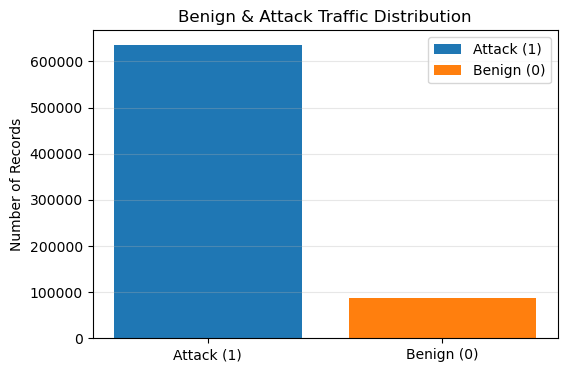

In [181]:
print("Benign and Attack Traffic Distribution:")
print("---------------------------------------")

# Display the distribution of labels in count
label_valuecounts = consolidated_df["Label"].value_counts()

# Calculate the sum of traffic (benign + attack)
label_sum = consolidated_df["Label"].value_counts().sum()

print(label_valuecounts)
print(f"\nSum of benign and attack traffic: {label_sum}")

# Display the percentage of distribution between benign and attack traffic
label_percentages = (label_valuecounts / label_sum) * 100
print("\nPercentage Distribution (%):")
print("----------------------------")
print(label_percentages.round(2))
print(f"\nTotal percentage = {label_percentages.sum().round(2)}%")

# Define a legend, where  0 = benign and 1 = attack traffic
# Plot a bar graph to show the distribution between benign and attack traffic
labels = ["Benign (0)", "Attack (1)"]
values = label_valuecounts.values

plt.figure(figsize=(6, 4))
plt.bar(0, values[0], label="Attack (1)")
plt.bar(1, values[1], label="Benign (0)")

plt.xticks([1, 0], labels)
plt.ylabel("Number of Records")
plt.title("Benign & Attack Traffic Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

Attack Category Distribution:
-----------------------------
Attack Name
Recon Port Scan             453291
Benign Traffic               86507
Recon Ping Sweep             47123
Recon OS Scan                42173
Recon Vulnerability Scan     39489
Dictionary Brute Force       18151
DoS SYN Flood                15243
MITM ARP Spoofing            14768
DoS UDP Flood                 1847
DoS DNS Flood                 1702
DoS ICMP Flood                1404
Recon Host Discovery           424
Name: count, dtype: int64

Sum of attack records accross all categories: 722122

Percentage Distribution of Attacks (%):
---------------------------------------
Attack Name
Recon Port Scan             62.77
Benign Traffic              11.98
Recon Ping Sweep             6.53
Recon OS Scan                5.84
Recon Vulnerability Scan     5.47
Dictionary Brute Force       2.51
DoS SYN Flood                2.11
MITM ARP Spoofing            2.05
DoS UDP Flood                0.26
DoS DNS Flood                

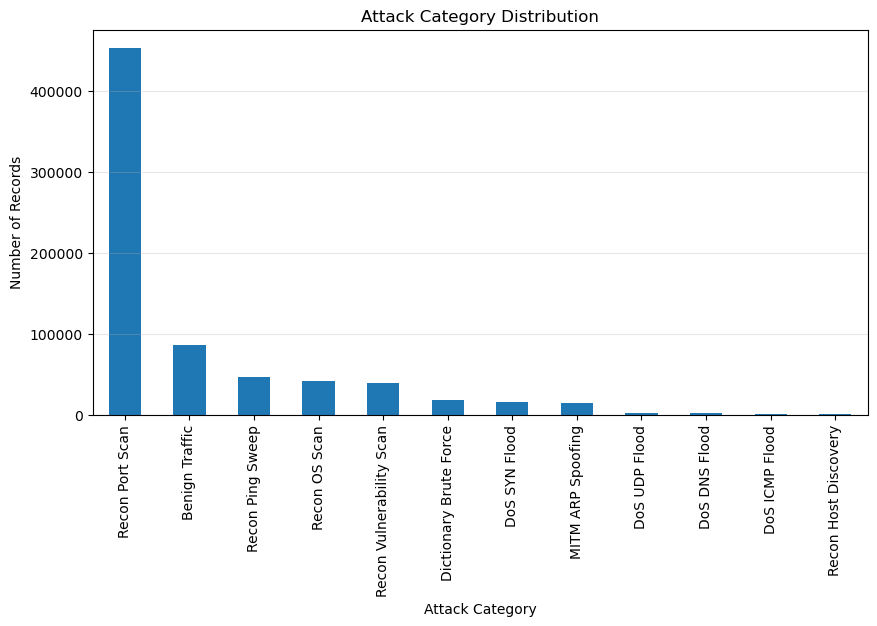

In [182]:
print("Attack Category Distribution:")
print("-----------------------------")

# Display the count of records for each attack category
attack_counts = consolidated_df["Attack Name"].value_counts()

# Calculate the sum of attack records
attack_sum = consolidated_df["Attack Name"].value_counts().sum()

print(attack_counts)
print(f"\nSum of attack records accross all categories: {attack_sum}")

# Display the percentage distribution of records for each attack category
attack_percentages = (attack_counts / attack_sum) * 100
print("\nPercentage Distribution of Attacks (%):")
print("---------------------------------------")
print(attack_percentages.round(2))
print(f"\nTotal percentage = {attack_percentages.sum().round(2)}%")

# Plot a bar graph to show the distribution of records for each attack category
attack_counts.plot(kind="bar", figsize=(10, 5))
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.title("Attack Category Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 5.3. Class Balancing

In [183]:
# Splitting the dataset into attack and benign samples
attack_df = consolidated_df[consolidated_df['Label'] == 1]
benign_df = consolidated_df[consolidated_df['Label'] == 0]

# Attack category distribution
attack_counts = attack_df['Attack Name'].value_counts()
attack_sum = attack_counts.sum()
attack_ratios = attack_counts / attack_sum

# Define the balancing, Target total attacks = total benign
# Total number of attack samples shld match benign
target_attack_total = len(benign_df)
print("Target Total Attacks:", target_attack_total)

# Target sample count per attack category
target_per_attack = (attack_ratios * target_attack_total).round().astype(int)

# Fix rounding
# Rounding may cause the sum of attacks to differ from total
# Difference is corrected by adding to the largest attack category
diff = target_attack_total - target_per_attack.sum()
if diff != 0:
    largest_attack = target_per_attack.idxmax()
    target_per_attack.loc[largest_attack] += diff

print("Final Total Attacks:", target_per_attack.sum())

# Stratified sampling
# Each catefory randomly sampled according to the target size
scaled_attack_dfs = []
for attack_name, n_samples in target_per_attack.items():
    category_df = attack_df[attack_df['Attack Name'] == attack_name]
    n_samples = max(int(n_samples), 0)  # safety
    sampled_df = category_df.sample(n=n_samples, random_state=42)
    scaled_attack_dfs.append(sampled_df)

attack_scaled_df = pd.concat(scaled_attack_dfs, ignore_index=True)

# Construct final balanced datset
# Benign samples are combiend with proportionally scaled attack samples
# Shuffled to remove bias
balanced_df = pd.concat([benign_df, attack_scaled_df], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

Target Total Attacks: 86507
Final Total Attacks: 86507



Balanced Label Counts:
----------------------
Label
0    86507
1    86507
Name: count, dtype: int64

Balanced Label Percentages (%):
-------------------------------
Label
0    50.0
1    50.0
Name: proportion, dtype: float64

Total percentage = 100.0%


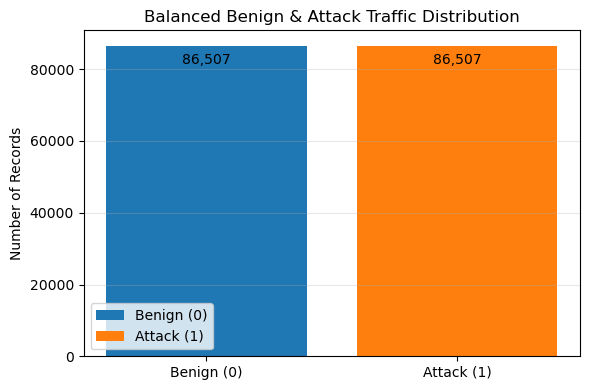

In [184]:
# Confirm that the final dataset is balanced by inspecting class count and percentage
balanced_counts = balanced_df['Label'].value_counts().sort_index()
balanced_percent = (balanced_df['Label'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nBalanced Label Counts:")
print("----------------------")
print(balanced_counts)

print("\nBalanced Label Percentages (%):")
print("-------------------------------")
print(balanced_percent)
print(f"\nTotal percentage = {balanced_percent.sum().round(2)}%")

# Plot balanced benign vs attack bar chart (values inside)
labels = ["Benign (0)", "Attack (1)"]
values = balanced_counts.values  # [benign, attack]

plt.figure(figsize=(6, 4))
bar0 = plt.bar(0, values[0], label="Benign (0)")
bar1 = plt.bar(1, values[1], label="Attack (1)")

plt.bar_label(bar0, fmt='{:,.0f}', padding=-15)
plt.bar_label(bar1, fmt='{:,.0f}', padding=-15)

plt.xticks([0, 1], labels)
plt.ylabel("Number of Records")
plt.title("Balanced Benign & Attack Traffic Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Scaled Attack Counts:
---------------------
Attack Name
Recon Port Scan             61693
Recon Ping Sweep             6413
Recon OS Scan                5740
Recon Vulnerability Scan     5374
Dictionary Brute Force       2470
DoS SYN Flood                2075
MITM ARP Spoofing            2010
DoS UDP Flood                 251
DoS DNS Flood                 232
DoS ICMP Flood                191
Recon Host Discovery           58
Name: count, dtype: int64

Scaled Attack Percentages (%):
------------------------------
Attack Name
Recon Port Scan             71.32
Recon Ping Sweep             7.41
Recon OS Scan                6.64
Recon Vulnerability Scan     6.21
Dictionary Brute Force       2.86
DoS SYN Flood                2.40
MITM ARP Spoofing            2.32
DoS UDP Flood                0.29
DoS DNS Flood                0.27
DoS ICMP Flood               0.22
Recon Host Discovery         0.07
Name: count, dtype: float64

Total percentage = 100.0%


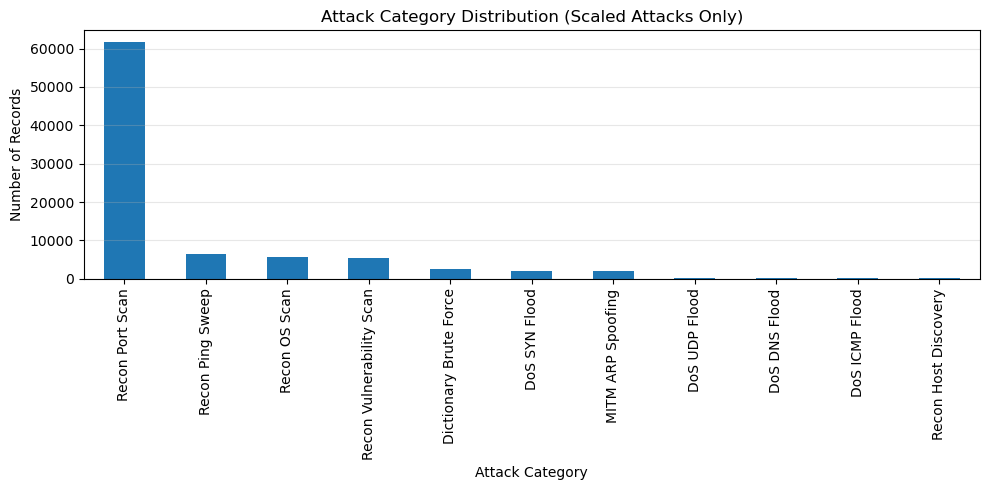

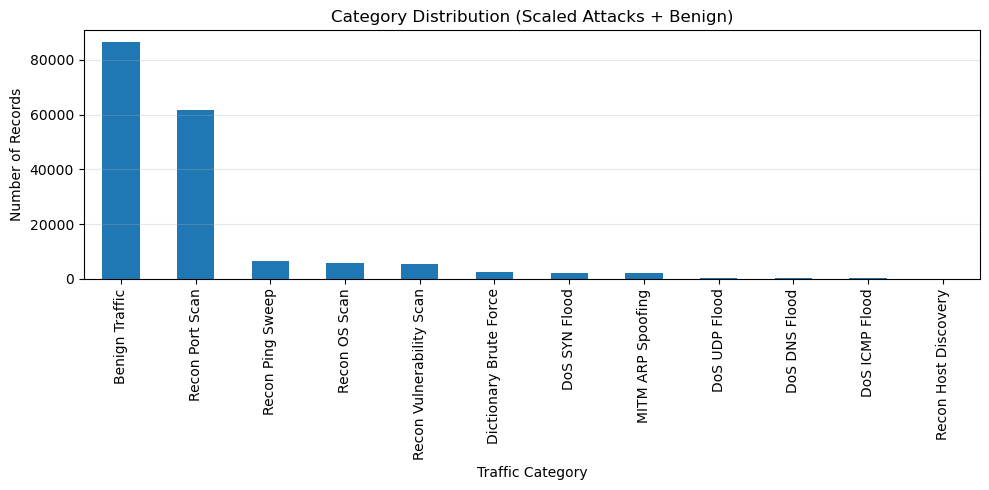

In [185]:
# Count number of samples per attack category after scaling
scaled_counts = attack_scaled_df['Attack Name'].value_counts()

# Convert attack counts into percentage distribution
scaled_percentages = (scaled_counts / scaled_counts.sum()) * 100

# Display scaled attack counts
print("Scaled Attack Counts:")
print("---------------------")
print(scaled_counts)

# Display scaled attack percentages
print("\nScaled Attack Percentages (%):")
print("------------------------------")
print(scaled_percentages.round(2))
print(f"\nTotal percentage = {scaled_percentages.sum().round(2)}%")

# Plot distribution of attack categories after scaling
plt.figure(figsize=(10, 5))
scaled_counts.plot(kind="bar")

# Label plot axes and title
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.title("Attack Category Distribution (Scaled Attacks Only)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Combine attack counts with benign traffic for comparison
# Add benign traffic count as a separate category
# Sort categories so dominant traffic types appear first
combined_counts = scaled_counts.copy()
combined_counts.loc["Benign Traffic"] = len(benign_df)
combined_counts = combined_counts.sort_values(ascending=False)

# Plot combined attack and benign traffic distribution
plt.figure(figsize=(10, 5))
combined_counts.plot(kind="bar")

plt.xlabel("Traffic Category")
plt.ylabel("Number of Records")
plt.title("Category Distribution (Scaled Attacks + Benign)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5.4. Univariate Feature Distribution

Univariate distribution refers to the analysis of individual features to understand their properties. It allows us to uncover information such as its range, central tendency, skewness and outliers within the network traffic. Univariate feature distribution reveals any abnormalities such as heavy-tailed or skewed behaviour and highlights potential outliers, which can influence our decisions in the later stages of the data science lifecycle.

Univariate Feature Distribition Statistics:
-------------------------------------------


,Flow Duration,Total Fwd Packet,Total Bwd packets,Packet Length Mean,Flow IAT Mean,Active Mean,Idle Mean
count,1.730140e+05,173014.000000,173014.000000,173014.000000,1.730140e+05,1.730140e+05,1.730140e+05
mean,7.349152e+06,18.794791,24.954709,114.531765,1.106351e+06,1.114401e+05,3.921038e+06
std,1.558658e+07,325.013997,429.395852,416.483504,2.802879e+06,8.066184e+05,9.682165e+06
min,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1%,1.000000e+00,1.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
5%,2.190000e+02,1.000000,0.000000,0.000000,2.040000e+02,0.000000e+00,0.000000e+00
25%,3.505000e+03,1.000000,1.000000,0.000000,3.321000e+03,0.000000e+00,0.000000e+00
50%,9.423500e+03,1.000000,1.000000,1.333333,5.877686e+03,0.000000e+00,0.000000e+00
75%,4.404605e+05,4.000000,3.000000,39.285714,5.858343e+04,0.000000e+00,0.000000e+00
90%,4.067511e+07,10.000000,10.000000,386.714286,6.063668e+06,2.615960e+04,1.510281e+07


Univariate Feature Distribition Visualisations:
-----------------------------------------------

Distribution of Features Using Histograms:


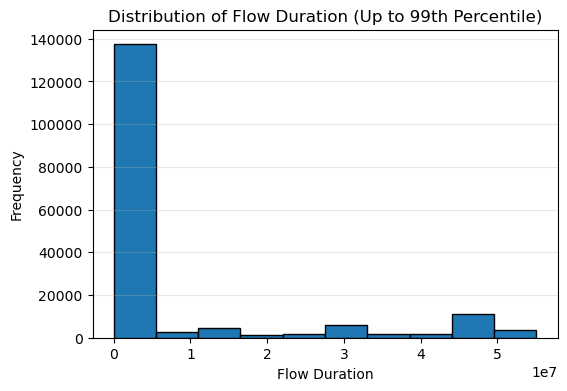

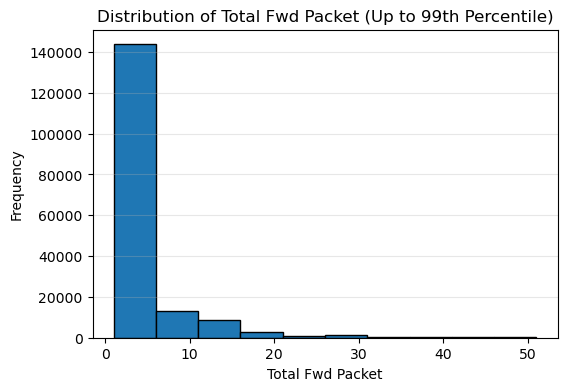

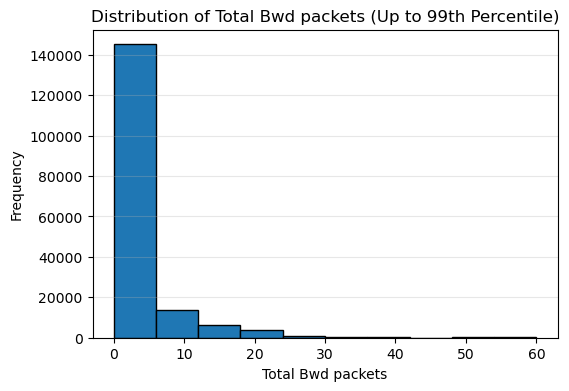

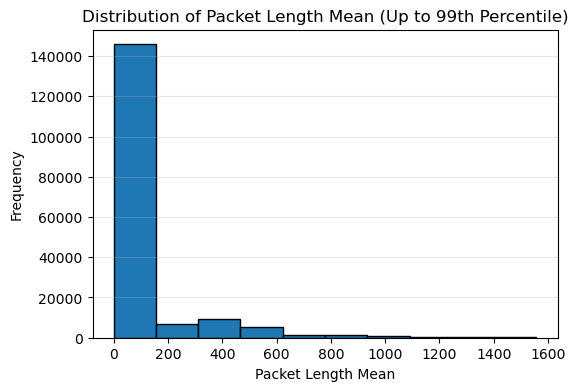

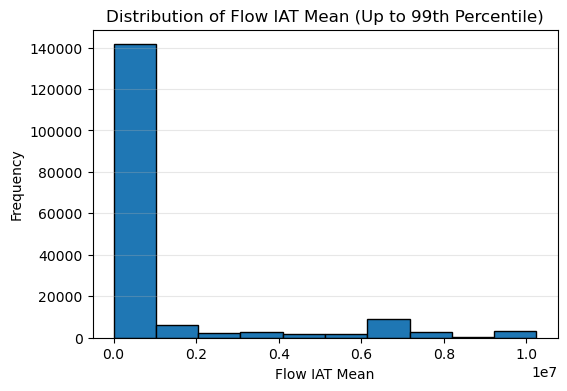

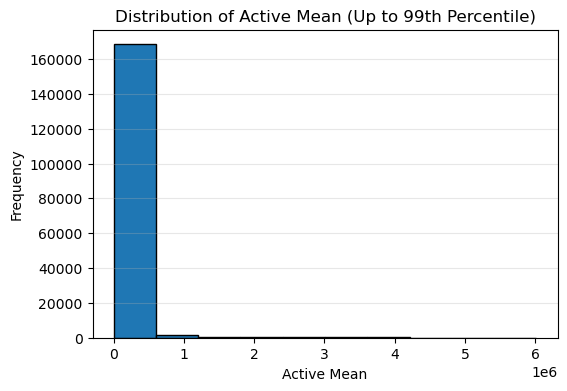

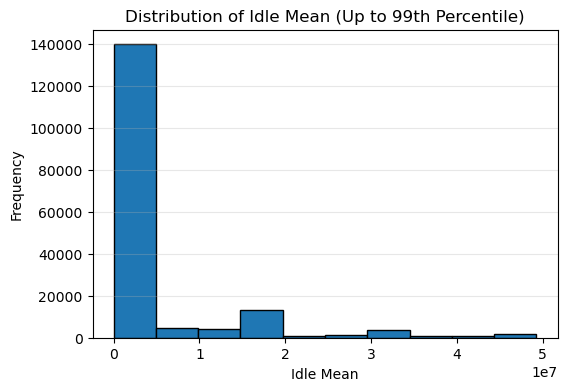


Distribution of Features Using Boxplots:


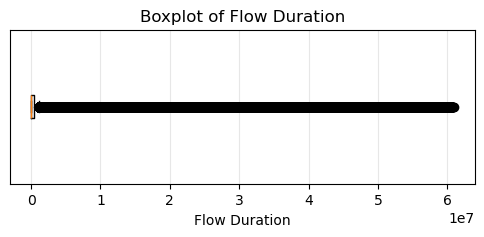

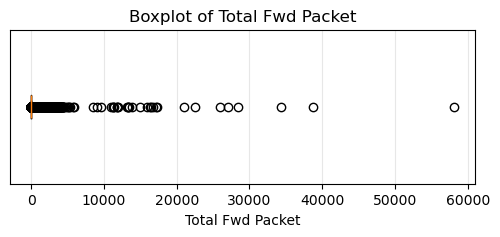

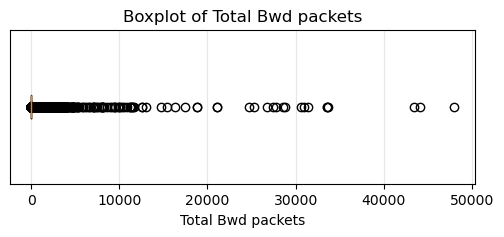

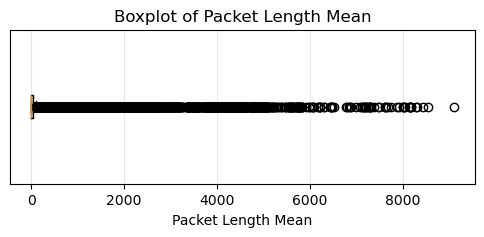

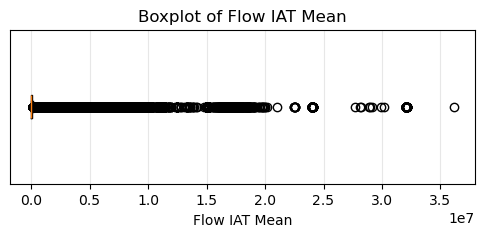

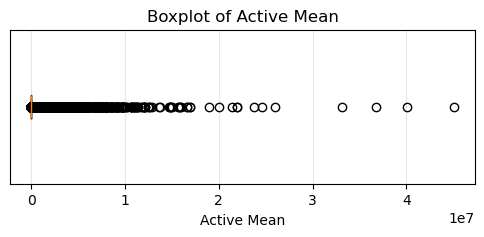

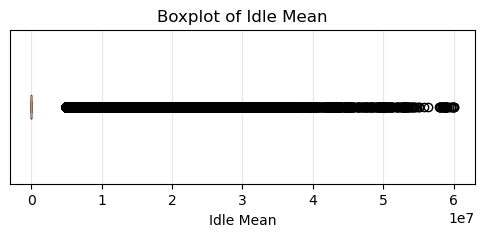

In [186]:
# Identify relevant numeric features that can represent network semantic groups
identified_features = [
    "Flow Duration",          # Flow-level behaviour
    "Total Fwd Packet",       # Packet count (forward direction)
    "Total Bwd packets",      # Packet count (backward direction)
    "Packet Length Mean",     # Packet size behaviour
    "Flow IAT Mean",          # Timing behaviour
    "Active Mean",            # Activity period behaviour
    "Idle Mean"               # Idle period behaviour
]

print("Univariate Feature Distribition Statistics:")
print("-------------------------------------------")

# Obtain statistics of the features identified
# Common percentiles: Q1, Median, Q3, 1st 5th 90th, 95th and 99th percentile
# Percentiles help to understand extreme outliers and understnd overall distribution
univariate_summary = balanced_df[identified_features].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
display(univariate_summary)

print("Univariate Feature Distribition Visualisations:")
print("-----------------------------------------------")

print("\nDistribution of Features Using Histograms:")
# Create a histogram to display the distribution of the features
for feature in identified_features:
    
    # Calculates the 99th percentile value of the feature
    # Using 99th percentile ensures that extreme outliers do not distort the scale
    # Visualials created focuses on normal traffic behaviour
    upper_bound = balanced_df[feature].quantile(0.99)

    # Selects the feature that we want to analyse,
    # For the feature selected, only display values that are less than or equal to the 99th percentile
    # Top 1% are treated as extreme values and outliers, hence they are excluded
    # Displays the results using a histogram
    plt.figure(figsize=(6, 4))
    plt.hist(
        balanced_df[feature][balanced_df[feature] <= upper_bound],
        bins=10,
        edgecolor="black",
    )
    
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature} (Up to 99th Percentile)")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

print("\nDistribution of Features Using Boxplots:")
# Create a boxplot to display the distribution of the features
for feature in identified_features:
    
    plt.figure(figsize=(6, 2))

    # Uses a boxplot distribution of the features
    plt.boxplot(balanced_df[feature], vert=False)

    # Defines axis
    # x-axis is the feature name, y-axis is kept empty as each box plot only represents the feature we are plotting
    plt.xlabel(feature)
    plt.yticks([])
    plt.title(f"Boxplot of {feature}")
    plt.grid(axis="x", alpha=0.3)
    plt.show()


The histogram displays relevant numeric network traffic features including flow flow durations, total forward packets, total backward packets, packet length mean, flow inter-arrival times, active mean and idle means. Through plotting the histogram, we are able to observe that the distribution of these features are heavily right-skewed. This means that a large number of records are concentrated at the lower values. In context of network traffic, it means that most network flows and packet behaviour are short-lived and lower in voume. Visusalisations are limited to display up to the 99th perscentile as it ensures that extreme values and outliers do not distort the visual causing inaccuracies and misinterpretation.

The boxplots highlights the presence of outliers across all features identified. These outliers may represent abnormal network traffic behaviour or indicators of attacks. Most features show a higher concentration of values near the lower values with some individual values at the far end of the box, highlighting a right-skewed behaviour.

## 5.5. Feature Behaviour Across Attack Categories

This section analyses the behaviour of the numeric features identied in the prior sections across attack categories. It compares the median network semantic behaviour across benign and attack categories which helps to identify differences in behaviours that may allow us to differentiate differneces between benign and attack network traffic. 

In [187]:
print("Feature Behaviour Across Attack Categories:")
print("-------------------------------------------")

behaviour_df = balanced_df.copy()

# Group the attacks by their names and identify the median values for the features identifeid in prior sections
# # Median is used due to skewed and heavy-tailed network traffic distributions
# Allows us to identify potential indicators of benign and attack traffic
feature_medians = (behaviour_df.groupby("Attack Name")[identified_features].median())
display(feature_medians)

Feature Behaviour Across Attack Categories:
-------------------------------------------


,Flow Duration,Total Fwd Packet,Total Bwd packets,Packet Length Mean,Flow IAT Mean,Active Mean,Idle Mean
Attack Name,,,,,,,
Benign Traffic,202254.0,3.0,2.0,26.419355,3.847550e+04,0.0,0.0
Dictionary Brute Force,82713.5,3.0,2.0,23.285714,1.522225e+04,0.0,0.0
DoS DNS Flood,395841.5,3.0,3.0,29.250000,1.617434e+05,0.0,0.0
DoS ICMP Flood,861347.0,3.0,2.0,21.000000,7.151582e+04,0.0,0.0
DoS SYN Flood,3117624.0,3.0,0.0,2.000000,1.558826e+06,0.0,0.0
DoS UDP Flood,202467.0,3.0,3.0,24.250000,3.870050e+04,0.0,0.0
MITM ARP Spoofing,213099.5,4.0,4.0,85.714286,1.475837e+04,0.0,0.0
Recon Host Discovery,272439.5,3.0,3.0,28.000000,3.918425e+04,0.0,0.0
Recon OS Scan,4227.5,1.0,1.0,0.000000,4.057500e+03,0.0,0.0


This analysis reveals behaviour differences across network semantics of benign and attack categories.

Based on the medians of each attack category, we can observe the following:
- Flow Duration: Flooding traffic exhibits higher median flow durations than benign traffic, while reconnaissance traffic exhibits shorter durations. This pattern is consistent with sustained traffic generation versus short-lived probe flows.
- Flow IAT Mean: Reconnaissance traffic shows higher inter-arrival times compared to benign traffic. This is consistent with the presence of spaced or non-continuous packet transmissions commonly associated with probing activity.
- Packet Length Mean: Near-zero packet lengths are observed primarily in SYN flooding and reconnaissance traffic, while other flooding attacks retain payload sizes similar to benign traffic. This aligns with traffic types such as reconnaissance scanning, that consists of primarily protocol headers with minimal or no payloads.


## 5.6. Protocol and TCP Flag Behaviour

This section analyses the protocols and TCP flag behaviours across benign and attack traffic categoreis. It focuses on protocol distribution and the useage of TCP SYN, ACK, RST flags. Median values ware used due to skewed and heavy-tailed nature of the network traffic dataset. This section assesses the behaviour of protocols and flags.

In [188]:
print("Protocol Distribution Across Attack Categories:")
print("-----------------------------------------------")

# Protocol used for each attack category and the value count
protocols = (balanced_df.groupby("Attack Name")["Protocol"].value_counts())
display(protocols)

print(f"\nTotal counts of attacks: {protocols.sum()}")

# Defines a list of all TCP flags within the dataset
tcp_flag_features = [
    "SYN Flag Count",
    "ACK Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "PSH Flag Count",
    "URG Flag Count",
    "CWR Flag Count",
    "ECE Flag Count"
]

# Check whether any TCP flags have zero variance across the dataset.
# Flags with no variation provide no discriminative value and should be excluded from further analysis and modelling
print("\nTCP Flag Verification:")
print("----------------------")

tcp_flag_variability = balanced_df[tcp_flag_features].describe()
display(tcp_flag_variability)

# Median values are used due to the skewed and heavy-tailed
# Nature of network traffic distributions
print("\nTCP Flag Behaviour Across Attack Categories (Median):")
print("-----------------------------------------------------")

tcp_flag_medians = (consolidated_df.groupby("Attack Name")[tcp_flag_features].median())

display(tcp_flag_medians)


Protocol Distribution Across Attack Categories:
-----------------------------------------------


Attack Name               Protocol
Benign Traffic            6           86507
Dictionary Brute Force    6            2470
DoS DNS Flood             6             232
DoS ICMP Flood            6             191
DoS SYN Flood             6            2075
DoS UDP Flood             6             251
MITM ARP Spoofing         6            2010
Recon Host Discovery      6              58
Recon OS Scan             6            5740
Recon Ping Sweep          6            6413
Recon Port Scan           6           61693
Recon Vulnerability Scan  6            5374
Name: count, dtype: int64


Total counts of attacks: 173014

TCP Flag Verification:
----------------------


,SYN Flag Count,ACK Flag Count,RST Flag Count,FIN Flag Count,PSH Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count
count,173014.000000,173014.000000,173014.000000,173014.000000,173014.000000,173014.000000,173014.000000,173014.000000
mean,0.830181,43.058822,0.498122,0.267718,14.078745,0.000393,0.000133,0.000202
std,0.871944,737.065492,0.532000,0.565800,172.804160,0.024749,0.011529,0.018465
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,6.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000
max,7.000000,102152.000000,2.000000,3.000000,10197.000000,2.000000,1.000000,2.000000



TCP Flag Behaviour Across Attack Categories (Median):
-----------------------------------------------------


,SYN Flag Count,ACK Flag Count,RST Flag Count,FIN Flag Count,PSH Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count
Attack Name,,,,,,,,
Benign Traffic,0.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
Dictionary Brute Force,0.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
DoS DNS Flood,0.0,6.0,0.0,0.0,2.0,0.0,0.0,0.0
DoS ICMP Flood,0.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0
DoS SYN Flood,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
DoS UDP Flood,0.0,6.0,0.0,0.0,2.0,0.0,0.0,0.0
MITM ARP Spoofing,2.0,8.0,0.0,0.0,3.0,0.0,0.0,0.0
Recon Host Discovery,0.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0
Recon OS Scan,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


TCP protocol and flag analysis was conducted to assess if connection-based indicators were able to help us differentiate indicators of benign and attack traffic. However, using medians of TCP flag count, the results did not display any characteristics of typical flows and differentiation across traffic categories. Median-based TCP flag summaries are ineffective in capturing any behavioural differences in network traffic within our dataset.

## 5.7. Correlation and Multicollinearity

Correlation helps to examine the relationships between numeric features to identify how strongly they are related. In network traffic datasets, since many features are derived from similar measurements such as packet count and statistics, they can be highly correlated to each other. 

Multicollinearity refers to highly correlated features that captures overlapping information. Identifying multicollinearity is important as it can affect model interpretability and lead to inaccuracies.

This section allows us to analyse correlation among numeric features and dientify potential redundency in the dataset.

Correlation Heatmap:
--------------------


<Axes: >

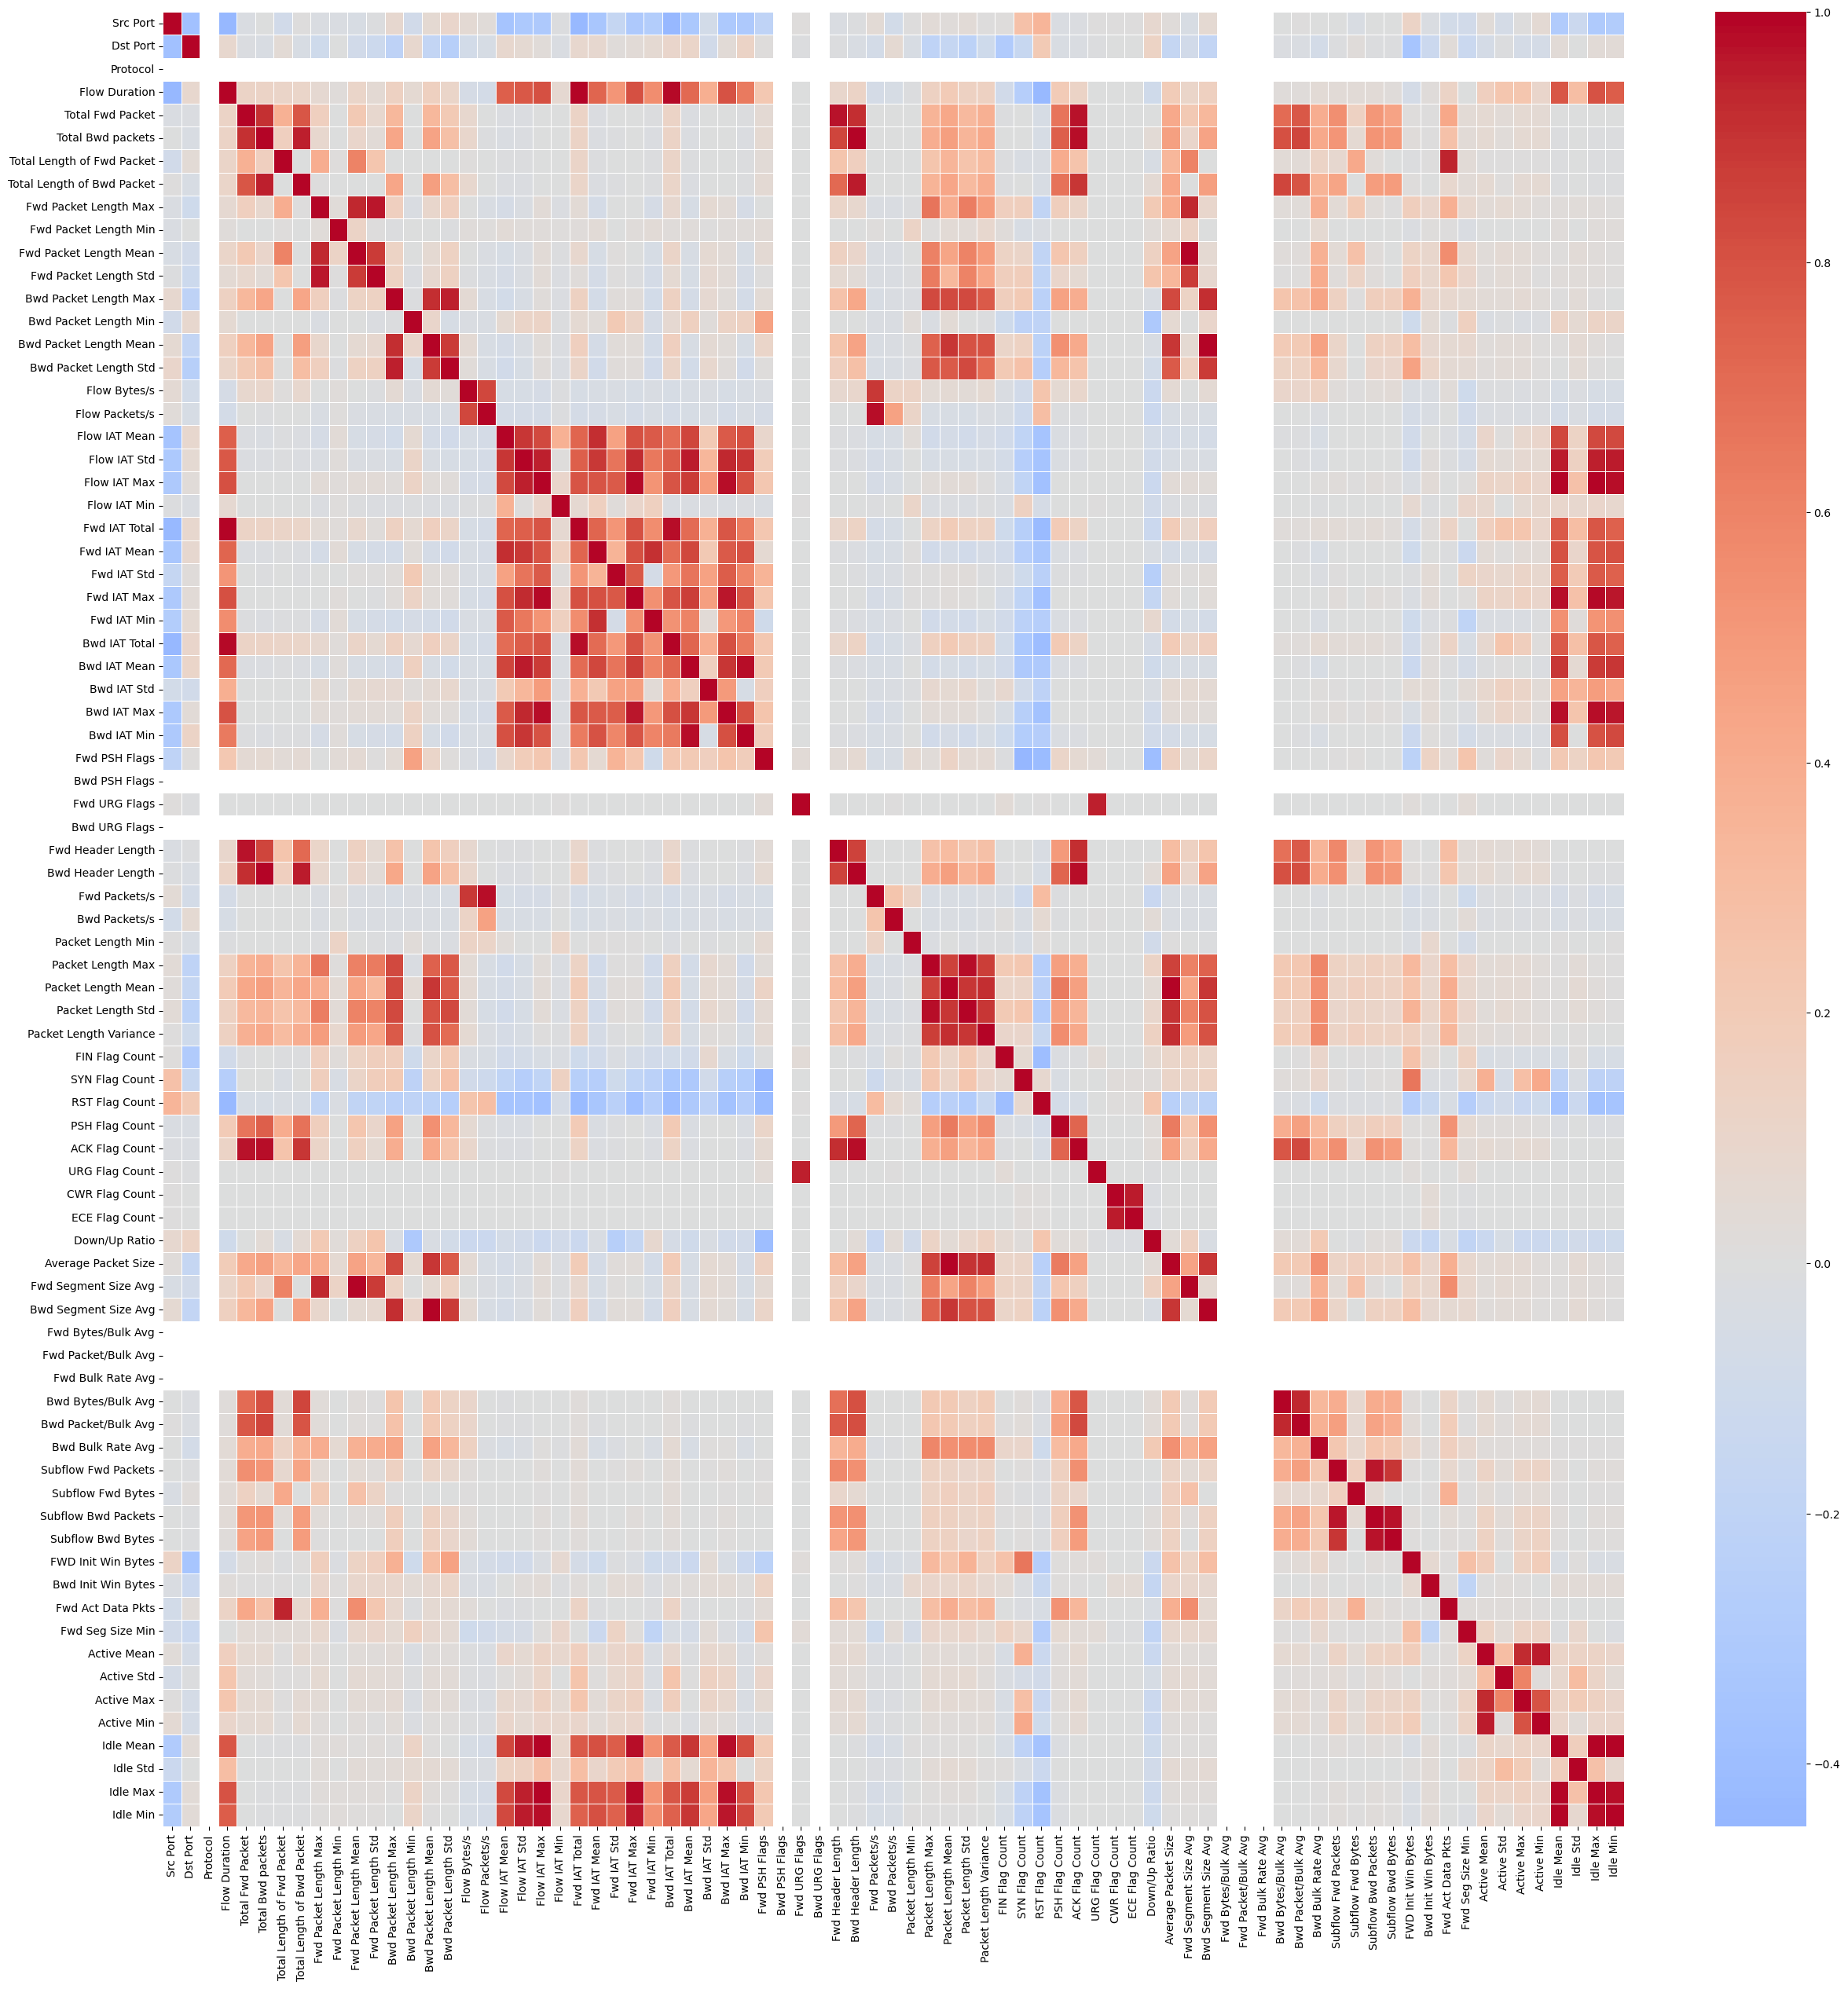

In [189]:
print("Correlation Heatmap:")
print("--------------------")

# Calculate for correlation, display correlation using a heatmap
# Colour intensity displays the strength of correlation,
# Orange = Stronger positive correlation, Blue = Negative correlation

numeric_df = balanced_df.select_dtypes(include=["int64", "float64"])

# Remove target / label-related columns if present
target_columns = ["Label"]
numeric_features = numeric_df.drop(columns=[col for col in target_columns if col in numeric_df.columns])

plt.figure(figsize=(30,30))
correlation = numeric_features.corr(numeric_only = True)
sns.heatmap(correlation,cmap="coolwarm",center=0,linewidths=0.5)

In [190]:
# Defining the correlation threshold
# Any correlation above 0.85 will be considered high
threshold = 0.85

# Empty list to store correlated pairs
pairs = []

# Caluclate correlation matrix
corr = numeric_df.corr()

# Loops through correlation columns and identifies a pair of features
# Features identified exceeds the defined threshold and is appended to the list of pairs
for i in range(len(corr.columns)):

    # i + 1 prevents the feature from comparing against itself (removes duplicate pairs)
    for j in range(i + 1, len(corr.columns)):

        # If a pair is identified, a dictionary is created
        # Key = columns, Value = data
        if abs(corr.iloc[i, j]) >= threshold:
            pairs.append({
                "Feature 1": corr.columns[i],
                "Feature 2": corr.columns[j],
                "Correlation": corr.iloc[i, j]
            })

# Convert the dictionaries into DataFrame
high_corr_pairs = pd.DataFrame(pairs)

# Displays all rows of the DataFrame created
pd.set_option("display.max_rows", None)

# Start index from 1 instead of 0
high_corr_pairs.index = range(1, len(high_corr_pairs) + 1)

display(high_corr_pairs)



,Feature 1,Feature 2,Correlation
1,Flow Duration,Fwd IAT Total,0.992720
2,Flow Duration,Bwd IAT Total,0.984280
3,Total Fwd Packet,Total Bwd packets,0.907225
4,Total Fwd Packet,Fwd Header Length,0.967742
5,Total Fwd Packet,Bwd Header Length,0.915061
6,Total Fwd Packet,ACK Flag Count,0.969507
7,Total Bwd packets,Total Length of Bwd Packet,0.947002
8,Total Bwd packets,Bwd Header Length,0.991900
9,Total Bwd packets,ACK Flag Count,0.982645
10,Total Length of Fwd Packet,Fwd Act Data Pkts,0.940193


## 5.8 Excluding Outliers

Excluding Outliers require identifying and removing data points that can affect the normal distribution of the data. In our network traffic dataset, outliers can cause abnormal spikes in certain features. While outliers may be real attack behaviour, it can also be the result of logging errors or extremes of the attack category.

By handling outliers, extreme values can tip the scale and disrupt our model's accuracy where there might be linear relationships. Without excluding outliers, it will reduce the model's learning and identifying patterns

In [191]:
# Define columns that should not undergo outlier capping
exclude_cols = [
    "Label", "Attack Name", "Protocol",
    "Src Port", "Dst Port"
]

# Select all numeric features from the balanced dataset
numeric_features = balanced_df.select_dtypes(include="number").columns

# Remove excluded categorical or identifier-like numeric columns
numeric_features = [col for col in numeric_features if col not in exclude_cols]

# Create a copy of the dataset to preserve the original values
balanced_df_capped = balanced_df.copy()

# Apply percentile-based capping to reduce extreme outliers
# Cap at 1st and 95th percentile
for col in numeric_features:
    lower = balanced_df[col].quantile(0.01)
    upper = balanced_df[col].quantile(0.95)
    
    # Cap values outside the percentile range
    balanced_df_capped[col] = balanced_df[col].clip(lower, upper)

# Generate statistical summary before and after outlier handling
summary_before = balanced_df[numeric_features].describe()
summary_after  = balanced_df_capped[numeric_features].describe()

# Display key statistics to compare distribution changes
print("Statistical Summary Before:")
print("---------------------------")
display(summary_before.loc[["min", "mean", "std", "max"]])

print("\nStatistical Summary After:")
print("--------------------------")
display(summary_after.loc[["min", "mean", "std", "max"]])

Statistical Summary Before:
---------------------------


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
min,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
mean,7.349152e+06,18.794791,24.954709,2.802116e+04,1.188804e+05,367.305368,1.869375,80.603960,130.427030,632.101472,...,6.737091,26.213162,1.114401e+05,3.204746e+04,1.505461e+05,9.075019e+04,3.921038e+06,1.800723e+05,4.069686e+06,3.778123e+06
std,1.558658e+07,325.013997,429.395852,7.826217e+05,2.650705e+06,1713.378572,40.486399,377.268687,584.727645,2267.377152,...,127.574467,5.367862,8.066184e+05,3.281067e+05,9.780769e+05,7.685831e+05,9.682165e+06,1.296310e+06,9.911942e+06,9.559052e+06
max,6.094632e+07,58077.000000,47939.000000,4.524739e+07,2.646032e+08,36936.000000,15533.000000,15533.000000,8766.514414,64860.000000,...,11185.000000,44.000000,4.505494e+07,2.337132e+07,4.505494e+07,4.505494e+07,6.003996e+07,3.109286e+07,6.003996e+07,6.003996e+07



Statistical Summary After:
--------------------------


,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
min,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
mean,7.082507e+06,3.282451,3.074508,397.546735,875.666750,153.455374,1.154456,37.979995,57.725236,428.066895,...,1.352029,25.922480,7670.749469,0.039869,8510.710573,5634.611082,3.464481e+06,4371.185871,3.626237e+06,3.320896e+06
std,1.483680e+07,3.780988,4.208067,1029.805653,2170.718647,353.822992,2.251991,82.584184,129.969205,1059.346442,...,2.497738,4.796066,23439.430587,0.146357,26238.266877,17434.709738,7.918473e+06,15711.237004,8.242201e+06,7.756793e+06
max,4.533193e+07,14.000000,16.000000,4246.350000,7551.000000,1333.000000,6.000000,329.071429,498.732795,4001.350000,...,9.000000,32.000000,93901.400000,0.577350,107332.100000,70613.700000,2.948506e+07,66545.324203,2.993603e+07,2.947146e+07


Here we can observed the diffences in the features after excluding the outliers. We can see that there was some decreases in features for their mean, std and max

In [192]:
# Generate statistical summaries for numeric features before capping
stats_before = balanced_df[numeric_features].describe()

# Generate statistical summaries for numeric features after capping
stats_after  = balanced_df_capped[numeric_features].describe()

# Build a comparison table for spread-related metrics
spread_comparison = pd.DataFrame({
    "max_before": stats_before.loc["max"],
    "max_after": stats_after.loc["max"],
    "std_before": stats_before.loc["std"],
    "std_after": stats_after.loc["std"]
})

# Calculate percentage reduction in maximum values
spread_comparison["max_reduction_%"] = (
    (spread_comparison["max_before"] - spread_comparison["max_after"])
    / spread_comparison["max_before"] * 100
)

# Calculate percentage reduction in standard deviation
spread_comparison["std_reduction_%"] = (
    (spread_comparison["std_before"] - spread_comparison["std_after"])
    / spread_comparison["std_before"] * 100
)

# Identify features with significant outlier impact
outlier_impact = spread_comparison[
    (spread_comparison["max_reduction_%"] > 20) |
    (spread_comparison["std_reduction_%"] > 20)
].sort_values("max_reduction_%", ascending=False)

# Display the first 10 features most affected by outlier capping
print("Quantitative Validatison of Outlier Capping:")
print("--------------------------------------------")
display(outlier_impact.head(10))


Quantitative Validatison of Outlier Capping:
--------------------------------------------


,max_before,max_after,std_before,std_after,max_reduction_%,std_reduction_%
Fwd URG Flags,1.000000e+00,0.00000,1.682663e-02,0.000000,100.000000,100.000000
URG Flag Count,2.000000e+00,0.00000,2.474907e-02,0.000000,100.000000,100.000000
CWR Flag Count,1.000000e+00,0.00000,1.152911e-02,0.000000,100.000000,100.000000
ECE Flag Count,2.000000e+00,0.00000,1.846548e-02,0.000000,100.000000,100.000000
Active Std,2.337132e+07,0.57735,3.281067e+05,0.146357,99.999998,99.999955
Subflow Bwd Bytes,2.348240e+08,1024.70000,1.034768e+06,232.124558,99.999564,99.977567
Total Length of Bwd Packet,2.646032e+08,7551.00000,2.650705e+06,2170.718647,99.997146,99.918108
Subflow Fwd Bytes,3.251031e+07,1116.00000,1.547770e+05,257.546189,99.996567,99.833602
Bwd Bytes/Bulk Avg,2.646049e+08,11171.00000,2.113437e+06,3142.637422,99.995778,99.851302
Total Length of Fwd Packet,4.524739e+07,4246.35000,7.826217e+05,1029.805653,99.990615,99.868416


We then made a display showing the before and after effects of exluding the outliers as well as the percentage reduction.

In [193]:
ioc_features = [
    "Protocol",
    "Dst Port",
    
    # Flow behaviour 
    "Flow Duration",
    "Flow Packets/s",
    "Flow Bytes/s",
    "Down/Up Ratio",

    # Packet volume & direction
    "Total Fwd Packet",
    "Total Bwd packets",
    "Total Length of Fwd Packet",
    "Total Length of Bwd Packet",
    "Fwd Act Data Pkts",

    # Timing irregularities
    "Flow IAT Mean",
    "Flow IAT Std",

    # Packet size behaviour
    "Packet Length Mean",
    "Packet Length Std",

    # TCP flag behaviour (selective)
    "SYN Flag Count",
    "ACK Flag Count",
    "RST Flag Count",

    # Header anomalies
    "Fwd Header Length",
    "Bwd Header Length"
]
final_columns = ioc_features + ["Attack Name", "Label"]

balanced_df_ioc = balanced_df_capped[final_columns].copy()

print("Final IoC Feature Count:",
      balanced_df_ioc.select_dtypes(include="number").shape[1])


Final IoC Feature Count: 21


# 6. Feature Engineering

Feature engineering is the process of transforming raw data into meaningful features that better represent the underlying problem for machine learning models. It involves creating, selecting, and transforming variables using domain knowledge to improve model performance and interpretability. Effective feature engineering helps models learn relevant patterns more accurately while reducing noise and redundancy in the dataset.

In [194]:
benign_df = balanced_df_ioc[balanced_df_ioc["Label"] == 0]

benign_thresholds = benign_df[ioc_features].quantile(0.90)

In [195]:
# DoS variants (IoCs only)
dos_dns_flood_iocs = {
    "high_packet_rate": "Flow Packets/s",
    "high_byte_rate": "Flow Bytes/s",
    "high_fwd_packets": "Total Fwd Packet",
    "high_fwd_bytes": "Total Length of Fwd Packet",
    "payload_activity": "Fwd Act Data Pkts",
    "packet_imbalance": "Down/Up Ratio",
    "timing_irregularity": "Flow IAT Std",
}

dos_icmp_flood_iocs = {
    "high_packet_rate": "Flow Packets/s",
    "high_fwd_packets": "Total Fwd Packet",
    "high_fwd_bytes": "Total Length of Fwd Packet",
    "payload_activity": "Fwd Act Data Pkts",
    "packet_imbalance": "Down/Up Ratio",
    "timing_irregularity": "Flow IAT Std",
}

dos_syn_flood_iocs = {
    "high_packet_rate": "Flow Packets/s",
    "high_syn_count": "SYN Flag Count",
    "high_fwd_packets": "Total Fwd Packet",
    "low_response_volume": "Total Bwd packets",   
    "short_or_spiky_timing": "Flow IAT Std",
}

dos_udp_flood_iocs = {
    "high_packet_rate": "Flow Packets/s",
    "high_byte_rate": "Flow Bytes/s",
    "high_fwd_packets": "Total Fwd Packet",
    "high_fwd_bytes": "Total Length of Fwd Packet",
    "payload_activity": "Fwd Act Data Pkts",
    "packet_imbalance": "Down/Up Ratio",
    "timing_irregularity": "Flow IAT Std",
}


# MITM variant
mitm_arp_spoofing_iocs = {
    "bidirectional_packets": "Total Bwd packets",
    "packet_size_anomaly": "Packet Length Std",
    "header_anomaly_fwd": "Fwd Header Length",
    "header_anomaly_bwd": "Bwd Header Length",
    "timing_irregularity": "Flow IAT Std",
}

# Recon variants
recon_host_discovery_iocs = {
    "short_flows": "Flow Duration",
    "high_packet_rate": "Flow Packets/s",
    "many_forward_packets": "Total Fwd Packet",
    "timing_irregularity": "Flow IAT Std",
}

recon_os_scan_iocs = {
    "short_flows": "Flow Duration",
    "many_forward_packets": "Total Fwd Packet",
    "rst_activity": "RST Flag Count",
    "timing_irregularity": "Flow IAT Std",
}

recon_ping_sweep_iocs = {
    "short_flows": "Flow Duration",
    "high_packet_rate": "Flow Packets/s",
    "many_forward_packets": "Total Fwd Packet",
    "timing_irregularity": "Flow IAT Std",
}

recon_port_scan_iocs = {
    "short_flows": "Flow Duration",
    "many_forward_packets": "Total Fwd Packet",
    "rst_activity": "RST Flag Count",
    "timing_irregularity": "Flow IAT Std",
}

recon_vulnerability_scan_iocs = {
    "high_packet_rate": "Flow Packets/s",
    "high_byte_rate": "Flow Bytes/s",
    "many_forward_packets": "Total Fwd Packet",
    "high_fwd_bytes": "Total Length of Fwd Packet",
    "payload_activity": "Fwd Act Data Pkts",
    "timing_irregularity": "Flow IAT Std",
}

# Brute force (generic)
bruteforce_iocs = {
    "repeated_attempts": "Total Fwd Packet",
    "regular_timing": "Flow IAT Mean",
    "timing_variation": "Flow IAT Std",
    "packet_size_variation": "Packet Length Std",
    "payload_activity": "Fwd Act Data Pkts",
}

ATTACK_IOCS = {
    "BruteForce": bruteforce_iocs,

    "DoS_DNS_Flood": dos_dns_flood_iocs,
    "DoS_ICMP_Flood": dos_icmp_flood_iocs,
    "DoS_SYN_Flood": dos_syn_flood_iocs,
    "DoS_UDP_Flood": dos_udp_flood_iocs,

    "MITM_ARP_Spoofing": mitm_arp_spoofing_iocs,

    "Recon_Host_Discovery": recon_host_discovery_iocs,
    "Recon_OS_Scan": recon_os_scan_iocs,
    "Recon_Ping_Sweep": recon_ping_sweep_iocs,
    "Recon_Port_Scan": recon_port_scan_iocs,
    "Recon_Vulnerability_Scan": recon_vulnerability_scan_iocs,
}


In [196]:
# Define function to compute IOC score and triggered indicators for a single row
def compute_ioc_score(row, ioc_dict, thresholds):
    score = 0
    triggered = []

    # Check each IOC feature against its threshold
    for ioc_name, feature in ioc_dict.items():
        if row[feature] > thresholds[feature]:
            score += 1
            triggered.append(ioc_name)

    # Return total IOC score and list of triggered IOCs
    return score, triggered

# List to store dynamically created IOC score column names
score_cols = []

# Generate per-attack IOC score columns
for attack_name, iocs in ATTACK_IOCS.items():
    # Create a unique score column for each attack type
    col_name = f"{attack_name}_score"
    score_cols.append(col_name)

    # Start from zero
    balanced_df_ioc[col_name] = 0

    # Increment score when feature exceeds benign baseline threshold
    for ioc_name, feature in iocs.items():
        balanced_df_ioc[col_name] += (
            balanced_df_ioc[feature] > benign_thresholds[feature]
        ).astype(int)

# Final aggregated IoC score
balanced_df_ioc["ioc_score"] = balanced_df_ioc[score_cols].sum(axis=1)

# Display sample rows to verify IOC scoring logic
display(
    balanced_df_ioc[["Label", "Attack Name", "ioc_score"] + score_cols].head(10)
)
print("Total Attack Score Columns:", len(score_cols))

,Label,Attack Name,ioc_score,BruteForce_score,DoS_DNS_Flood_score,DoS_ICMP_Flood_score,DoS_SYN_Flood_score,DoS_UDP_Flood_score,MITM_ARP_Spoofing_score,Recon_Host_Discovery_score,Recon_OS_Scan_score,Recon_Ping_Sweep_score,Recon_Port_Scan_score,Recon_Vulnerability_Scan_score
0,0,Benign Traffic,4,0,0,0,0,0,0,1,1,1,1,0
1,1,Recon Port Scan,0,0,0,0,0,0,0,0,0,0,0,0
2,1,Recon Port Scan,9,0,1,1,1,1,0,1,1,1,1,1
3,1,Recon Port Scan,2,0,0,0,0,0,0,0,1,0,1,0
4,1,Recon Port Scan,2,0,0,0,0,0,0,0,1,0,1,0
5,0,Benign Traffic,0,0,0,0,0,0,0,0,0,0,0,0
6,0,Benign Traffic,0,0,0,0,0,0,0,0,0,0,0,0
7,1,Recon Vulnerability Scan,2,0,0,0,0,0,0,0,1,0,1,0
8,0,Benign Traffic,2,1,0,0,0,0,1,0,0,0,0,0
9,1,Recon Ping Sweep,2,0,0,0,0,0,0,0,1,0,1,0


Total Attack Score Columns: 11


In [ ]:
# So now with the score how will it know if it is bruteforce or DoS DNS_Flood?
# Identify all IOC score columns generated earlier
score_cols = [c for c in balanced_df_ioc.columns if c.endswith("_score")]

# Determine which attack types were triggered for a given row
def get_matching_attacks(row):
    return [
        col.replace("_score", "")
        for col in score_cols
        if row[col] > 0
    ]

# Apply attack-matching logic across all records
balanced_df_ioc["matched_attacks"] = balanced_df_ioc.apply(
    get_matching_attacks, axis=1
)

# Display sample rows to validate attack attribution logic
display(
    balanced_df_ioc[["Label", "Attack Name", "ioc_score", "matched_attacks"] + score_cols].head(10)
)

# 7. Data Modeling

Data modeling involves training machine learning models using prepared features to learn patterns and relationships within the data. In this stage, different models are trained and evaluated to assess their ability to accurately classify network traffic and detect attack behaviors. The goal is to identify a model that generalizes well and performs reliably on unseen data.

# Model 1: Baseline Classification Model

## 7.1. Splitting the Data into Features X and Target Y

In [ ]:
# Select IOC-based features as input variables
X = balanced_df_ioc[score_cols + ["ioc_score"]]

# Define binary target variable (benign vs attack)
y = balanced_df_ioc["Label"]

## 7.1.2. Train-Test Split and Feature Scaling

In [ ]:
# Split dataset into training and testing subsets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,        # 70% train, 30% test
    random_state=42,
    stratify=y            # preserve benign/attack ratio so that when you train test
                            # train 52% attack / 48% benign
                            # test 46% attack / 54% benign
)


# Standard scaler for feature normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7.1.3. Logistic Regression Model Training and Evaluation

In [ ]:
# logistic regression as a baseline classification model
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train logistic regression model on scaled training data
logreg.fit(X_train_scaled, y_train)

# Generate predictions using test data
predictions = logreg.predict(X_test_scaled)

# Generate predictions on unseen test data
# Display confusion matrix to visualise prediction errors
print("Logistic Regression Evaluation:")
print("-------------------------------")

print("\nClassification Report:")
print("----------------------")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print("-----------------")
print(confusion_matrix(y_test, predictions))


## 7.1.4. Random Forest Model Training and Evaluation

In [ ]:
# Initialise Random Forest as a non-linear ensemble comparison model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train Random Forest model on the training dataset
rf_model.fit(X_train, y_train)

# Prediction
predictions = rf_model.predict(X_test)

print("Random Forest Model Evaluation:")
print("-------------------------------")

# Display classification performance metrics
print("\nClassification Report:")
print("----------------------")
print(classification_report(y_test, predictions))

# Display confusion matrix for error analysis
print("\nConfusion Matrix:")
print("-----------------")
print(confusion_matrix(y_test, predictions))

# Model 2: Balanced Multiclass Classification Model

## 7.2.1. Class Balancing using Resampling 

In [ ]:
# Create a working copy of the IOC-enhanced balanced dataset
# Assign explicit label name for benign traffic
df = balanced_df_ioc.copy()
df.loc[df["Label"] == 0, "Attack Name"] = "Benign"

# Define target sample size per class
# Fix random state
SAMPLES_PER_CLASS = 2500
RANDOM_STATE = 42

# Resample each attack category to a fixed size
def sample_to_n(g):
    return resample(
        g, # basically it is each attack name dataframe then it will check the length
        replace=(len(g) < SAMPLES_PER_CLASS),  # oversample only if needed
        #the replace will be a true or false then the code will duplicate traffic
        #so that it reaches the target size which is SAMPLES_PER_CLASS = 2500
        n_samples=SAMPLES_PER_CLASS,
        random_state=RANDOM_STATE
    )

# Apply per-class resampling and shuffle the final dataset
balanced_df_2500 = (
    df.groupby("Attack Name", group_keys=False)# since we use groupby, basically it 
                                            #excludes the attack name say benign
      .apply(sample_to_n)
      .sample(frac=1, random_state=RANDOM_STATE)  # shuffle
      .reset_index(drop=True)
)

print("Class counts (Sample Size: 2500):")
print("---------------------------------")
print(balanced_df_2500["Attack Name"].value_counts())

## 7.2.2. Multiclass Logistic Regression Model Training

In [ ]:
# Select IOC-based score features as inputs for multiclass prediction
X = balanced_df_2500[score_cols + ["ioc_score"]]

# Set multiclass target as attack category name (includes "Benign")
y = balanced_df_2500["Attack Name"]

# Train / Test split (VERY important to stratify by Attack Name)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 7.2.3. Feature Scaling using StandardScaler

In [ ]:
# Initialise scaler to standardise feature ranges for logistic regression
scaler = StandardScaler()

# Fit on TRAIN only
X_train_scaled = scaler.fit_transform(X_train)

# Transform TEST
X_test_scaled = scaler.transform(X_test)

## 7.2.4. Logistic Regression Model Training and Evaluation

In [ ]:
# Initialise multiclass logistic regression model as a baseline classifier
logreg_multi = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class="auto"
)

# Train model on scaled training data
logreg_multi.fit(X_train_scaled, y_train)

# Predict attack category labels for the test set
pred_logreg = logreg_multi.predict(X_test_scaled)

print("Logistic Regression Evaluation:")
print("-------------------------------")

# Print evaluation metrics for multiclass classification performance
print("\nClassification Report:")
print("----------------------")
print(classification_report(y_test, pred_logreg))

# Print confusion matrix to analyse per-class misclassifications
print("\nConfusion Matrix:")
print("-----------------")
print(confusion_matrix(y_test, pred_logreg))

### 7.2.5. Random Forest Model Training and Evaluation

In [134]:
# Initialise Random Forest classifier for multiclass attack classification
rf_multi = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
)

# Train Random Forest model on the training dataset
rf_multi.fit(X_train, y_train)

# Generate multiclass predictions on the test dataset
pred_rf = rf_multi.predict(X_test)

# Print evaluation header for multiclass Random Forest
print("Random Forest Model Evaluation:")
print("-------------------------------")

# Print evaluation metrics for multiclass classification performance
print("\nClassification Report:")
print("----------------------")
print(classification_report(y_test, pred_rf))

# Print confusion matrix to analyse per-class misclassifications
print("\nConfusion Matrix:")
print("-----------------")
print(confusion_matrix(y_test, pred_rf))

Random Forest Model Evaluation:
-------------------------------

Classification Report:
----------------------
                          precision    recall  f1-score   support

                  Benign       0.34      0.07      0.12       750
  Dictionary Brute Force       0.40      0.24      0.30       750
           DoS DNS Flood       0.29      0.19      0.23       750
          DoS ICMP Flood       0.42      0.09      0.14       750
           DoS SYN Flood       0.20      0.97      0.33       750
           DoS UDP Flood       0.23      0.20      0.21       750
       MITM ARP Spoofing       0.57      0.08      0.13       750
    Recon Host Discovery       0.38      0.12      0.18       750
           Recon OS Scan       1.00      0.00      0.00       750
        Recon Ping Sweep       0.00      0.00      0.00       750
         Recon Port Scan       0.29      0.21      0.25       750
Recon Vulnerability Scan       0.23      0.76      0.36       750

                accuracy     

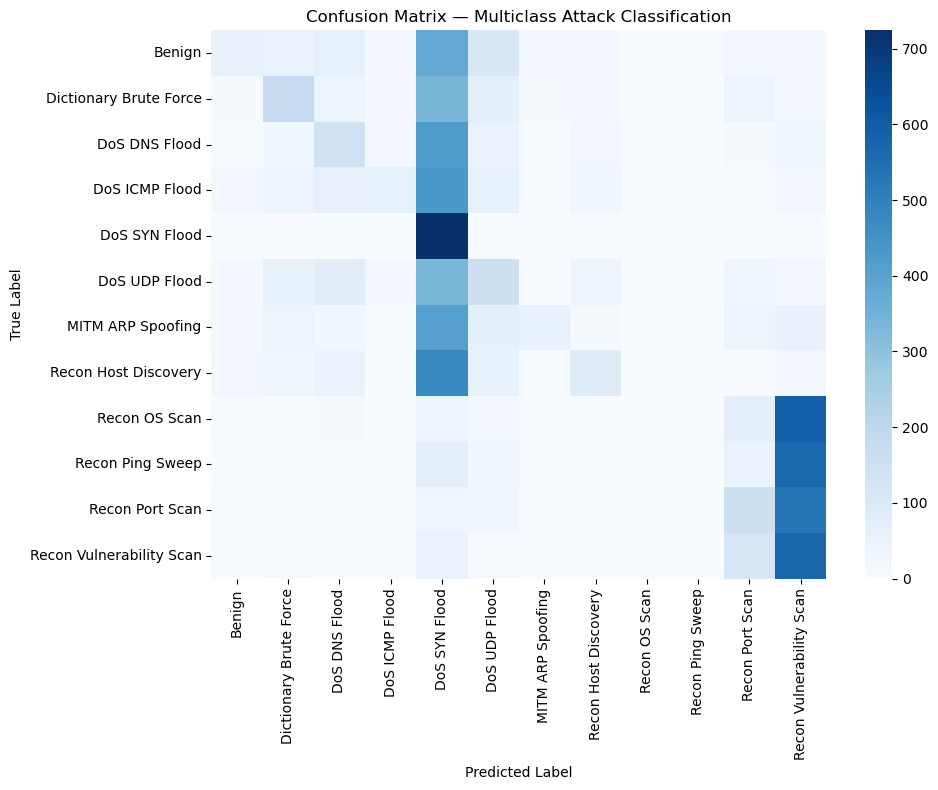

In [135]:
labels = rf_multi.classes_  # attack names

# Compute confusion matrix for multiclass Random Forest predictions
cm = confusion_matrix(y_test, pred_rf)

# Create figure for confusion matrix visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues",
    fmt="d"
)

# Label axes to indicate prediction direction
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add descriptive title for the confusion matrix
plt.title("Confusion Matrix — Multiclass Attack Classification")
plt.tight_layout()
plt.show()

# Model 2.1: Improved Multiclass Classification Model

For Model 2, we want to improve how the model decides the attack, since some attacks overlap in behaviour and the differences are very minimal. We realized that the features selected to calculate the scores was not comprehensive enough. While the initial Model 2 relied primarily on IoC-derived scores, performance was limited by information compression. To address this, a second iteration of Model 2 incorporated selected raw flow-level features capturing packet rate, timing irregularities, directional traffic imbalance, and header behaviour. These features were chosen based on known attack characteristics and allowed the model to learn nuanced inter-attack differences directly from the data.

## 7.3.1. Class Balancing using Controlled Resampling

In [141]:
# Balance each class to a fixed number of samples using controlled resampling
def balance_classes_to_n(df, label_col, target_n, random_state=42):
    
    # Balance each class in `label_col` to exactly `target_n` samples.
    # Oversamples ONLY when a class has fewer than target_n samples.
    
    # Resample a single class group to the target size
    def _sample_group(g):
        return resample(
            g,
            replace=(len(g) < target_n),  # oversample only if needed
            n_samples=target_n,
            random_state=random_state
        )
        
    # Apply resampling per class and shuffle the final dataset
    return (
        df.groupby(label_col, group_keys=False)
          .apply(_sample_group)
          .sample(frac=1, random_state=random_state)  # shuffle
          .reset_index(drop=True)
    )

In [142]:
# Create a working copy of the capped dataset
ndf_model2 = balanced_df_capped.copy()

# Explicitly label benign traffic
ndf_model2.loc[ndf_model2["Label"] == 0, "Attack Name"] = "Benign"

# Apply controlled class balancing across all attack categories
ndf_model2_balanced = balance_classes_to_n(
    df=ndf_model2,
    label_col="Attack Name",
    target_n=2500
)

C:\Users\darri\AppData\Local\Temp\ipykernel_44628\2656317141.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_sample_group)


## 7.3.2. Feature and Target Preparation

In [155]:
# Define columns that should not be used as model features
exclude_cols = [
    "Label",
    "Attack Name",
]

# Remove target and identifier columns from feature set
nX_model2 = ndf_model2_balanced.drop(columns=exclude_cols)

# Keep only numeric columns
nX_model2 = nX_model2.select_dtypes(include="number")

# y = multi-class target
ny_model2 = ndf_model2_balanced["Attack Name"]

# Print feature matrix shape for validation
print(f"X shape: rows: {nX_model2.shape[0]} | columns: {nX_model2.shape[1]}")
print(f"y shape: rows: {ny_model2.shape[0]} |")

X shape: rows: 30000 | columns: 79
y shape: rows: 30000 |


## 7.3.3. Train-Test Split (Stratified by Attack Category)

In [156]:
# Split dataset into training and testing sets with class stratification
X2_train, X2_test, y2_train, y2_test = train_test_split(
    nX_model2,
    ny_model2,
    test_size=0.3,
    random_state=42,
    stratify=ny_model2
)

## 7.3.4. Robust Feature Scaling Using RobustScaler

In [157]:
# Initialise RobustScaler to reduce influence of remaining outliers
scaler_model2 = RobustScaler()

# Fit scaler on training data
X2_train_scaled = scaler_model2.fit_transform(X2_train)
X2_test_scaled  = scaler_model2.transform(X2_test)


## 7.3.5. Random Forest Model Training and Evaluation

In [158]:
# Initialise Random Forest with regularisation to control model complexity
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
)

# Train Random Forest model on scaled training data
rf_model2.fit(X2_train_scaled, y2_train)

# Generate predictions on the test dataset
y2_pred = rf_model2.predict(X2_test_scaled)

# Output evaluation metrics for multiclass classification
print("Random Forest Model Evaluation:")
print("-------------------------------")
print(classification_report(y2_test, y2_pred, zero_division=0))

Random Forest Model Evaluation:
-------------------------------
                          precision    recall  f1-score   support

                  Benign       0.58      0.48      0.53       750
  Dictionary Brute Force       0.78      0.54      0.64       750
           DoS DNS Flood       0.65      0.96      0.77       750
          DoS ICMP Flood       0.78      0.95      0.85       750
           DoS SYN Flood       1.00      0.90      0.95       750
           DoS UDP Flood       0.74      0.87      0.80       750
       MITM ARP Spoofing       0.84      0.67      0.75       750
    Recon Host Discovery       0.78      1.00      0.88       750
           Recon OS Scan       1.00      0.89      0.94       750
        Recon Ping Sweep       0.89      0.78      0.83       750
         Recon Port Scan       0.94      0.86      0.90       750
Recon Vulnerability Scan       0.99      0.94      0.96       750

                accuracy                           0.82      9000
          

# 8. Data Visualization

In data visualization, it is used to find the patterns and trends and the model's performance in a clear way, Visual tools like heatmaps have been utilized to illustrate the results, showing the strengths and weakness of our trained model.

## 8.1. Confusion Matrix Heatmap of Model 2 (New vs Old)"

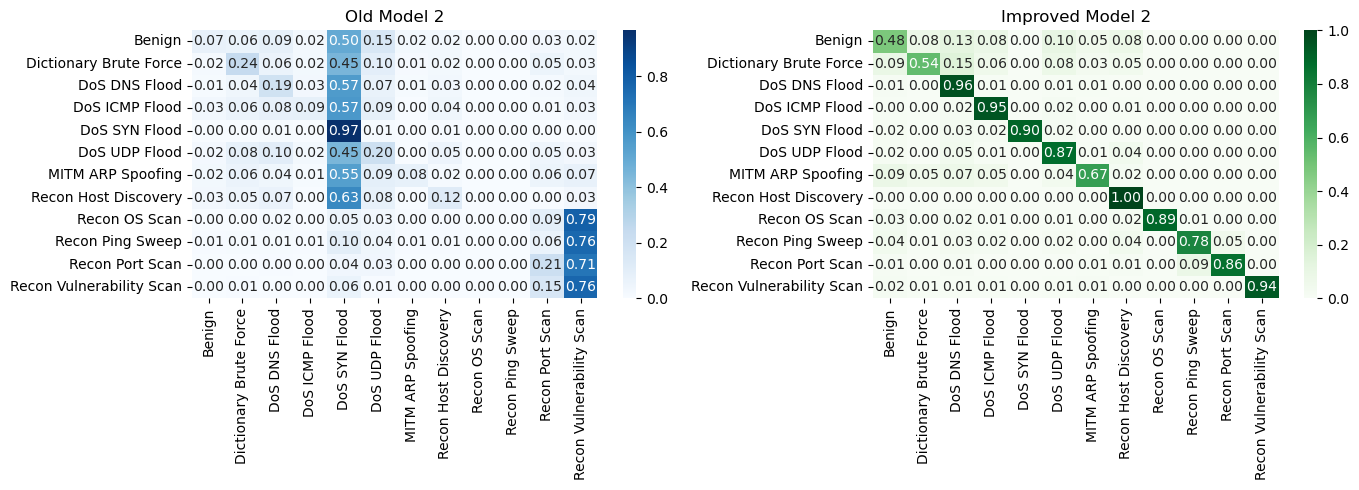

In [159]:
# Extract unique class labels for consistent axis ordering
labels = np.unique(y_test)

# Create side-by-side subplots for model comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot normalised confusion matrix for baseline model
sns.heatmap(
    confusion_matrix(y_test, pred_rf, labels=labels, normalize="true"),
    annot=True, fmt=".2f", cmap="Blues",
    xticklabels=labels, yticklabels=labels, ax=ax[0]
)

# Set title for baseline model heatmap
ax[0].set_title("Old Model 2")

# Plot normalised confusion matrix for enhanced model
sns.heatmap(
    confusion_matrix(y2_test, y2_pred, labels=labels, normalize="true"),
    annot=True, fmt=".2f", cmap="Greens",
    xticklabels=labels, yticklabels=labels, ax=ax[1]
)

# Set title for enhanced model heatmap
ax[1].set_title("Improved Model 2")

plt.tight_layout()
plt.show()